# **🐶 Multi-class Dog Breed Classification (Using TensorFlow 2.21.0 and Transfer Learning)**

This notebook builds and end-to-end multi-class image classifier using `TensorFlow 2.21.0` and `TensorFlow Hub`.

---

## **Some things to know**

### **1. Deep Learning**
Machine learning where the model **learns its own features** through many stacked layers (a neural network), instead of you hand-picking features manually.

"Deep" = many layers.

**Types of problem we have:**
1. Classification
2. Sequence to Sequece (seq2seq) (like audio)
3. Object detection, etc..

---

### **2. Neural Network (NN)**
A stack of layers, each made of neurons.

**Three layer types:**
- **Input layer** — passes your data in. 5 features = 5 neurons. No math here.
- **Hidden layer(s)** — where learning actually happens. Can have 1 or many.
- **Output layer** — the prediction. 1 neuron for regression, N neurons for N classes.

**What one neuron does:**
```
output = (x1 × w1) + (x2 × w2) + (x3 × w3) + ...
```
Each input is **multiplied** by a weight, then summed up.

**Weight** = a number that controls how much influence one input has.
- `w = 0.0` → ignore this input
- `w = 2.0` → this input matters a lot
- `w = -0.5` → this input pushes the decision the other way

**Learning = slowly adjusting all weights until predictions get accurate.**

![Neural Network](./assets/images/diagram2_nn_anatomy.png)

---

### **3. TensorFlow**
Google's framework for building and training neural networks.

It handles for you: matrix math, gradients, GPU acceleration, saving models.

You write the architecture. TensorFlow does the heavy lifting.

---

### **4. TensorFlow Hub**
A library of **pre-trained models** hosted by Google.

Instead of training from scratch (days + massive GPU), you grab a model that's already trained on millions of images and reuse it.

---

## **5. Transfer Learning**
Using a pre-trained model as a starting point for your own task.

```
TensorHub model (already trained)
        ↓
Freeze the base layers (keep what it learned)
        ↓
Add your own output layer on top
        ↓
Train only your new layers on your data
        ↓
Done — in minutes, not days
```

**Analogy:** A doctor who studied medicine for 10 years does a 6-month cardiology specialization. They don't relearn biology — they transfer existing knowledge.

![Analogy DL and tensorflow overview](./assets/images/diagram1_overview.png)

---

### **The Big Picture**

```
Your data
   → TensorFlow (the tool)
      → Neural Network (the model)
         → Pre-trained weights from TensorHub
            → Fine-tuned with Transfer Learning
               → Your prediction
```

---

> **Rule of thumb:** In real projects, you almost never train from scratch.
> Grab a model from TensorHub → freeze it → add your layer → train. That's the job.

---

**Back to our mental model:**

![ml-project-overview](./assets/images/matplotlib-6-step-ml-framework-tools-matplotlib-highlight.png)

Also we have **Google collab** in area space of jupyter notebook.

---

<div style="background-color: white; display: inline-block; padding: 8px;">
  <img src="./assets/images/unstructured-data-tesnorflow-workflow.png" alt="tensor-workflow" />
</div>

In [1]:
# from google.colab import drive # type: ignore
# drive.mount('/content/drive/')

In [2]:
# !unzip -q "/content/drive/MyDrive/dog-breed-identification.zip" -d "/content/drive/MyDrive/dog-vision-project-3"

## **1. Problem defination**

Identifying the breed of the dog given the image of the dog.

When I'm sitting at the cafe and I take photo of a dog, I want to know that what breed of the dog it is.

---

## **2. Data**

The data we're using is from [Kaggle's Dog Breed Identification Competition](https://www.kaggle.com/competitions/dog-breed-identification/data).

---

## **3. Evaluation**

The evaluation is a file with prediction probabilities for each dog breed of each test image.

[Here](www.kaggle.com/competitions/dog-breed-identification/overview/evaluation)

---

## **4. Features**

**Some information about the data:**
- We're are dealing with images (unstructred data) so it's probably we use deep learning/transfer learning.
- There are `120` breeds of dogs (this means there are 120 different classes).
- There are around `10,000+` images in the training set (these images have labels).
- There are around `10,000+` images in the test set (these images have no labels, because we'll want to predict them).


### **Get our workspace ready**

- Import TensorFlow 2.x ✅
- Import TensorFlow Hub ✅
- Make sure we're using a GPU ✅

In [3]:
import sys
print(sys.executable)

/home/eakempreet_singh/envs/dog-vision/bin/python


In [4]:
import os
# Use legacy Keras so older TensorFlow Hub / Keras code stays compatible in this notebook.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Import necesaary Tools from colab
import tensorflow as tf
import tensorflow_hub as hub

print("TF version:", tf.__version__)
print("TF Hub Version: ", hub.__version__)

# Native Windows TensorFlow >= 2.11 does not use CUDA GPUs directly.
gpu_devices = tf.config.list_physical_devices("GPU")
if os.name == "nt":
    print("Native Windows TensorFlow does not use CUDA GPUs in TF 2.11+.")
    print("If you want RTX 3050 acceleration locally, use WSL2 or TensorFlow-DirectML.")
else:
    print("GPU", "available (YES!!!!)" if gpu_devices else "not available :(")

2026-05-06 18:21:12.532927: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-06 18:21:15.126196: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF version: 2.16.1
TF Hub Version:  0.16.1
GPU available (YES!!!!)


2026-05-06 18:21:18.063437: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-06 18:21:18.379637: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-06 18:21:18.380132: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


**To select GPU:**
- go to `Kernal`
  - `Select another kernal`
    - `Collab`
      - `New Collab server`
        - `GPU`
          - `T4`  --> Gives you the GPU access default is CPU

In [5]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

## **Getting our data ready (turning into Tensors)**

With all machine learning models, our data has to be in numerical format. So that's what we'll be doing first.
Turning our **images** into **Tensors** (numerical representations).

Let's start by accessing our data and checking out the labels.

### **Quick switch note (Colab ↔ Local)**
- Run the next cell and change only `FORCE_ENV` (`"auto"`, `"colab"`, or `"local"`).
- After that, all paths should come from the path variables (`DATA_ROOT`, `TRAIN_DIR`, `LABELS_CSV`, `LOG_DIR`).
- No manual path edits needed in later cells.

In [6]:
import glob  # Provides filename pattern matching (wildcards)
from pathlib import Path
import os

# Set to "auto" (recommended), "colab", or "local"
FORCE_ENV = "auto"

def detect_env():
    in_colab = "COLAB_GPU" in os.environ or os.path.exists("/content")
    return "colab" if in_colab else "local"

ENV = detect_env() if FORCE_ENV == "auto" else FORCE_ENV

if ENV == "colab":
    PROJECT_ROOT = Path("/content/drive/MyDrive/dog-vision-project-3")
    DATA_ROOT = PROJECT_ROOT
else:
    PROJECT_ROOT = Path(".")
    DATA_ROOT = PROJECT_ROOT / "dataset" / "dog-breed-identification"

TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
LABELS_CSV = DATA_ROOT / "labels.csv"
LOG_DIR = PROJECT_ROOT / "logs"

print("ENV:", ENV)
print("DATA_ROOT:", DATA_ROOT)
print("Top folders:", glob.glob(str(DATA_ROOT / "*"))[:20])
print("labels.csv exists:", LABELS_CSV.exists())

ENV: local
DATA_ROOT: dataset/dog-breed-identification
Top folders: ['dataset/dog-breed-identification/labels.csv', 'dataset/dog-breed-identification/sample_submission.csv', 'dataset/dog-breed-identification/test', 'dataset/dog-breed-identification/train']
labels.csv exists: True


In [7]:
# Checkout the labels of our data
import pandas as pd
label_csv = pd.read_csv(LABELS_CSV)
print(label_csv.describe())
print()
print(label_csv.head())

                                      id               breed
count                              10222               10222
unique                             10222                 120
top     000bec180eb18c7604dcecc8fe0dba07  scottish_deerhound
freq                                   1                 126

                                 id             breed
0  000bec180eb18c7604dcecc8fe0dba07       boston_bull
1  001513dfcb2ffafc82cccf4d8bbaba97             dingo
2  001cdf01b096e06d78e9e5112d419397          pekinese
3  00214f311d5d2247d5dfe4fe24b2303d          bluetick
4  0021f9ceb3235effd7fcde7f7538ed62  golden_retriever


<details>
  <summary><b>Click to view setup summary</b></summary>

### 1. Mount Google Drive
- What we did: Connected the Colab runtime to Google Drive.
- Why: Colab GPU runs on a remote machine, so it needs Drive access to read your files.

### 2. Unzip the dataset
- What we did: Extracted dog-breed-identification.zip into your project folder on Drive.
- Why: Uploading one zip is easier, and training needs normal extracted folders and files.

### 3. Load labels.csv
- What we did: Read labels.csv using pandas from the extracted dataset path.
- Why: labels.csv maps each image to its breed, which is required for supervised training.

</details>

In [8]:
label_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


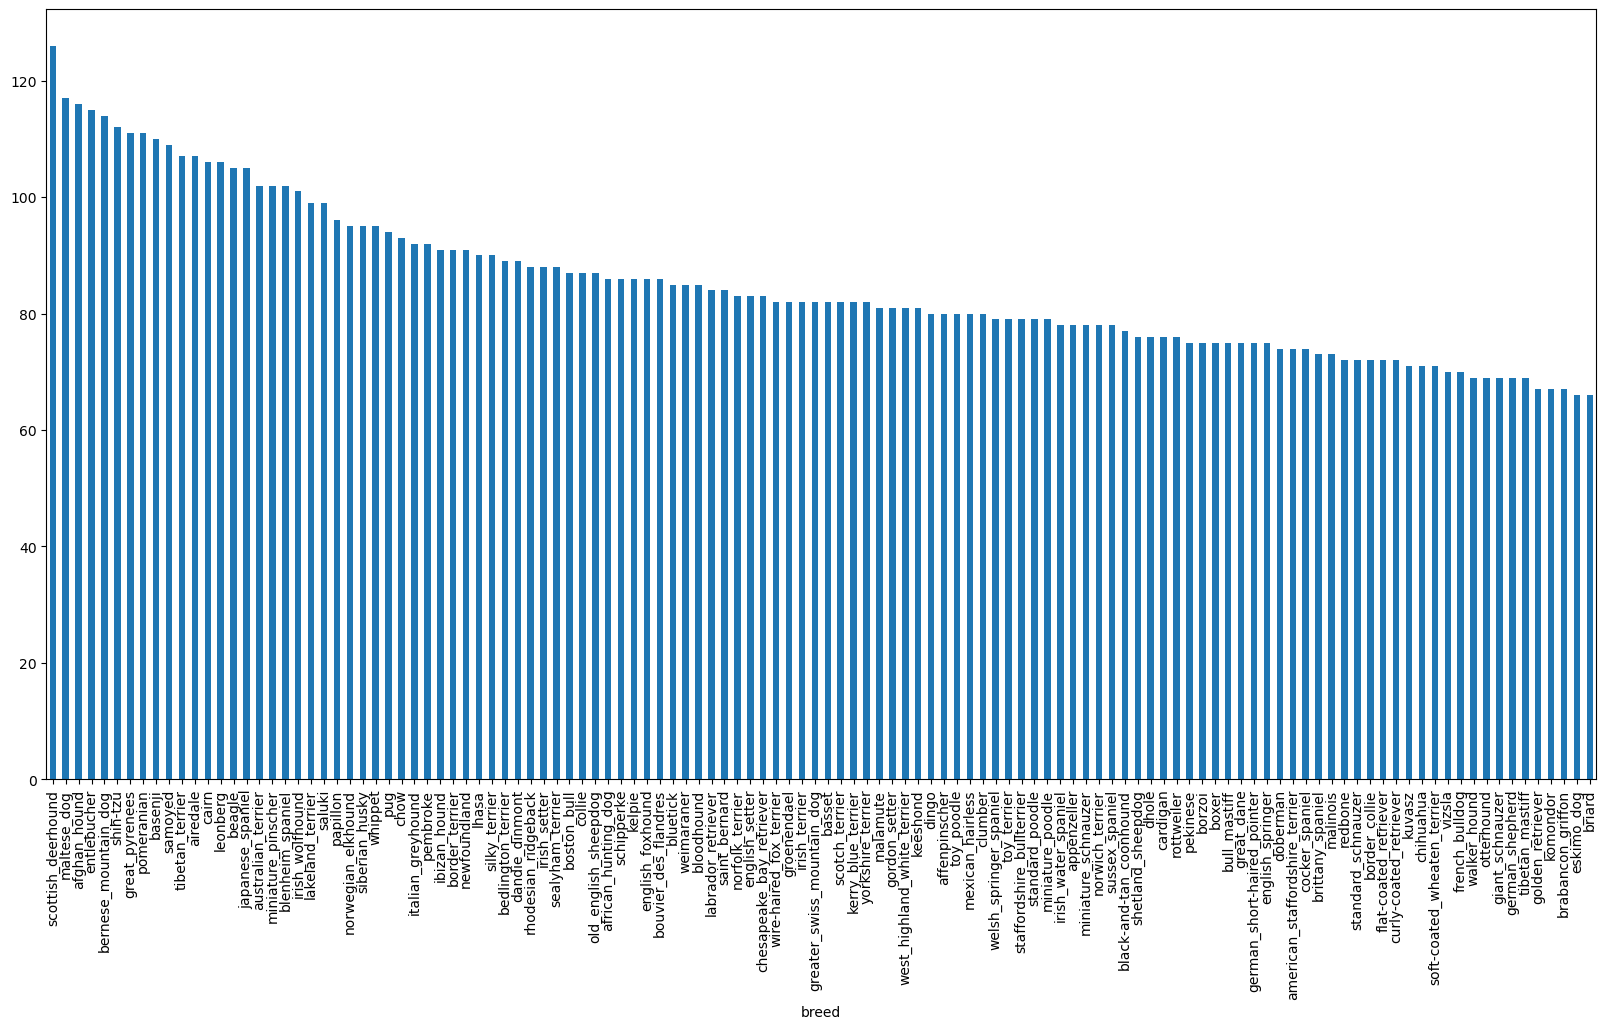

In [9]:
# How many images are there of each breed?
label_csv["breed"].value_counts().plot.bar(figsize=(20, 10));

In [10]:
label_csv['breed'].value_counts().median()

82.0

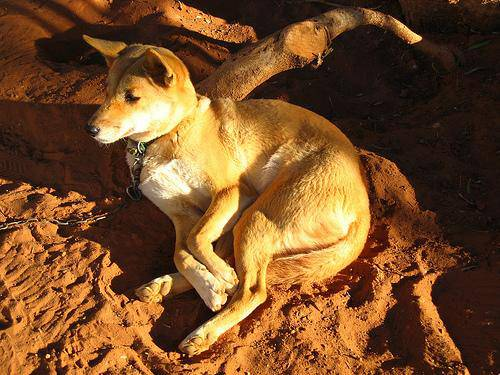

In [11]:
# Let's view an image
from IPython.display import Image
Image(str(TRAIN_DIR / "001513dfcb2ffafc82cccf4d8bbaba97.jpg"))

### **Getting images and thier labels**

Let's get a list of all of our image file pathnames

In [12]:
label_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [13]:
# Create pathnames from Image ID's
filenames = [str(TRAIN_DIR / f"{fname}.jpg") for fname in label_csv["id"]]

# Check the first 10
filenames[:10]

['dataset/dog-breed-identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'dataset/dog-breed-identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'dataset/dog-breed-identification/train/001cdf01b096e06d78e9e5112d419397.jpg',
 'dataset/dog-breed-identification/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'dataset/dog-breed-identification/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'dataset/dog-breed-identification/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 'dataset/dog-breed-identification/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'dataset/dog-breed-identification/train/002a283a315af96eaea0e28e7163b21b.jpg',
 'dataset/dog-breed-identification/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'dataset/dog-breed-identification/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [14]:
import os
os.listdir(TRAIN_DIR)[:10]

['000bec180eb18c7604dcecc8fe0dba07.jpg',
 '001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '001cdf01b096e06d78e9e5112d419397.jpg',
 '00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '0021f9ceb3235effd7fcde7f7538ed62.jpg',
 '002211c81b498ef88e1b40b9abf84e1d.jpg',
 '00290d3e1fdd27226ba27a8ce248ce85.jpg',
 '002a283a315af96eaea0e28e7163b21b.jpg',
 '003df8b8a8b05244b1d920bb6cf451f9.jpg',
 '0042188c895a2f14ef64a918ed9c7b64.jpg']

In [15]:
# Check whether number of filenames matches number of actual image files
import os
if len(os.listdir(TRAIN_DIR)) == len(filenames):
    print("Filnames matches actual amount of files!! Proceed.")
else:
    print("Filenames do NOT match the actual amount of files, check the target directory.")

Filnames matches actual amount of files!! Proceed.


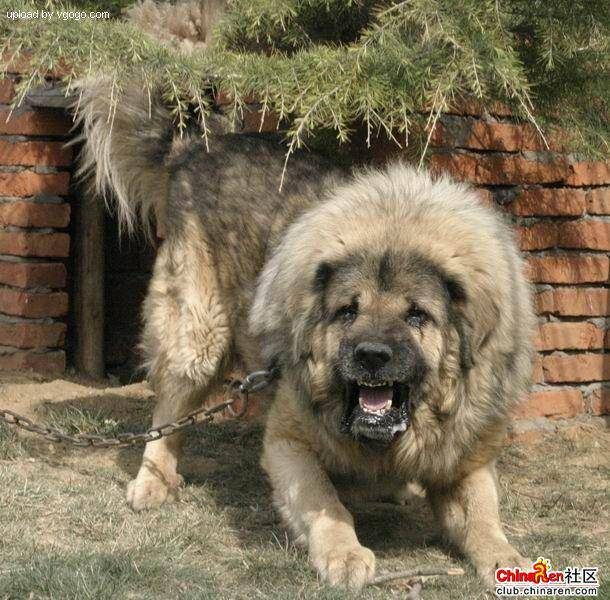

In [16]:
# One more check 
Image(filenames[9000])

In [17]:
label_csv["breed"][9000]

'tibetan_mastiff'

![tensor workflow](./assets/images/unstructured-data-tesnorflow-workflow.png)

**Since we've now got our training image filepaths in a list, lets's prepare our labels.**

In [18]:
import numpy as np
labels = label_csv["breed"].to_numpy()
# labels = np.array(labels) # does same thing as above
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [19]:
len(labels)

10222

In [20]:
# See if number of labels matches the number of filenames
if(len(labels)) == len(filenames):
    print("Number of labels matches number of filenames!!")
else:
    print("Number of labels does not match number of filenames, check data directories!!")

Number of labels matches number of filenames!!


In [21]:
# Find the unique labels values
unique_breeds = np.unique(labels)
len(unique_breeds) # Total 120 breeds of dogs

120

In [22]:
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [23]:
# Turn a single label into an array of booleans

print(labels[0])
labels[0] == unique_breeds

boston_bull


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [24]:
#  Turn every label into a boolean array
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [25]:
len(labels)

10222

In [26]:
len(boolean_labels)

10222

In [27]:
# Example: Turning booloean array into integers
print(labels[0])  # Original label
print(np.where(unique_breeds==labels[0]))  # index where labels occur
print(boolean_labels[0].argmax()) # index where labels occur in boolean array # argmax() returns the index of first True (or here maximum)
print(boolean_labels[0].astype(int)) # there will be a 1 where the sample label occurs

boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [28]:
print(labels[2])
print(np.where(unique_breeds==labels[2]))
print(boolean_labels[2].argmax())
print(boolean_labels[2].astype(int))

pekinese
(array([85]),)
85
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [29]:
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [30]:
filenames[:10]

['dataset/dog-breed-identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'dataset/dog-breed-identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'dataset/dog-breed-identification/train/001cdf01b096e06d78e9e5112d419397.jpg',
 'dataset/dog-breed-identification/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'dataset/dog-breed-identification/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'dataset/dog-breed-identification/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 'dataset/dog-breed-identification/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'dataset/dog-breed-identification/train/002a283a315af96eaea0e28e7163b21b.jpg',
 'dataset/dog-breed-identification/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'dataset/dog-breed-identification/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

### **Creating our own validation set**

Since the dataset from Kaggle doesn't come with a validation set, we're going to create our own.

In [31]:
# Set up X and y variables

X = filenames
y = boolean_labels

In [32]:
len(filenames)

10222

**We're are going to start off experimenting with ~1000 images and increase as needed.**

In [33]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    NUM_IMAGES = globals().get("NUM_IMAGES", 1000)
    slider = widgets.IntSlider(value=NUM_IMAGES, min=1000, max=10000, step=1000, description='NUM_IMAGES')
    label = widgets.Label(value=f'NUM_IMAGES = {NUM_IMAGES}')

    def on_value_change(change):
        globals()['NUM_IMAGES'] = change['new']
        label.value = f'NUM_IMAGES = {change["new"]}'

    slider.observe(on_value_change, names='value')
    display(slider, label)

except Exception as e:
    print("ipywidgets not available in this kernel:", e)
    print("\nRun these in your terminal (same env as kernel):")
    print("  pip install ipywidgets")
    print("  jupyter nbextension enable --py widgetsnbextension --sys-prefix")
    print("\nThen reload VS Code, restart kernel, and rerun this cell.")

IntSlider(value=1000, description='NUM_IMAGES', max=10000, min=1000, step=1000)

Label(value='NUM_IMAGES = 1000')

In [34]:
# Let's split our data into train and validation sets
from sklearn.model_selection import train_test_split

# np.random.seed(42)

# Split them into training and validation of total size NUM_IMAGES
X_train, X_val, y_train, y_val = train_test_split(X[:NUM_IMAGES],
                                                  y[:NUM_IMAGES],
                                                  test_size=0.2,
                                                  random_state=42)

len(X_train), len(X_val), len(y_train), len(y_val)

(800, 200, 800, 200)

In [35]:
# Let's have a geez on our training data
X_train[:5], y_train[:5]

(['dataset/dog-breed-identification/train/00bee065dcec471f26394855c5c2f3de.jpg',
  'dataset/dog-breed-identification/train/0d2f9e12a2611d911d91a339074c8154.jpg',
  'dataset/dog-breed-identification/train/1108e48ce3e2d7d7fb527ae6e40ab486.jpg',
  'dataset/dog-breed-identification/train/0dc3196b4213a2733d7f4bdcd41699d3.jpg',
  'dataset/dog-breed-identification/train/146fbfac6b5b1f0de83a5d0c1b473377.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, Fa

## **Preprocessing Images (turning Images into Tensors)**

To preprocess our images into Tensors, we're going to write a function which does a few things:
1. Take an image filepath as input
2. Use TensorFlow to read a file and save it to a variable `image`
3. Turn our `image` variable (a jpg) into Tensors
4. Normalize our `image` (convert colour channel values from 0-255 to 0-1).
5. Resize the `image` to be a shape of (224, 224)
6. Return the modified `image`

Before we do, let's see what importing an image looks like.

In [36]:
# Convert image to NumPy array
from matplotlib.pyplot import imread
image = imread(filenames[42])
image.shape # (Hight, width, colour_channel(RGB->0-255))

(257, 350, 3)

In [37]:
image.max(), image.min()

(255, 0)

In [38]:
image

array([[[ 89, 137,  87],
        [ 76, 124,  74],
        [ 63, 111,  59],
        ...,
        [ 76, 134,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  73],
        [ 67, 114,  68],
        [ 63, 111,  63],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 131,  86]],

       [[ 56, 104,  66],
        [ 58, 106,  66],
        [ 64, 112,  72],
        ...,
        [ 71, 127,  82],
        [ 73, 129,  84],
        [ 73, 130,  85]],

       ...,

       [[  2,  11,  10],
        [  5,  14,  13],
        [  6,  15,  14],
        ...,
        [120, 113,  67],
        [126, 118,  72],
        [122, 114,  67]],

       [[  0,   4,   6],
        [  0,   9,   8],
        [  1,  10,   9],
        ...,
        [105,  98,  52],
        [111, 104,  58],
        [111, 103,  56]],

       [[ 18,  16,  37],
        [ 18,  18,  28],
        [ 17,  20,  11],
        ...,
        [101,  92,  53],
        [ 97,  88,  49],
        [120, 111,  72]]

In [39]:
image[:2]

array([[[ 89, 137,  87],
        [ 76, 124,  74],
        [ 63, 111,  59],
        ...,
        [ 76, 134,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  73],
        [ 67, 114,  68],
        [ 63, 111,  63],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 131,  86]]], dtype=uint8)

In [40]:
# Convert image into tensor
tf.constant(image)[:2]

2026-05-06 18:21:26.874679: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-06 18:21:26.875202: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-06 18:21:26.875416: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-06 18:21:27.462610: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-06 18:21:27.462774: I external/local_xla/xla/stream_executor

<tf.Tensor: shape=(2, 350, 3), dtype=uint8, numpy=
array([[[ 89, 137,  87],
        [ 76, 124,  74],
        [ 63, 111,  59],
        ...,
        [ 76, 134,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  73],
        [ 67, 114,  68],
        [ 63, 111,  63],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 131,  86]]], dtype=uint8)>

In [41]:
image = imread(filenames[0])
# returns a NumPy array 
image.shape

(375, 500, 3)

In [42]:
image = tf.constant(image)
image.shape

TensorShape([375, 500, 3])

**Now we've seen what an image looks like as a Tensor, let's make a fucntion to preprocess them.**

1. Take an image filepath as input
2. Use TensorFlow to read a file and save it to a variable `image`
3. Turn our `image` variable (a jpg) into Tensors
4. Normalize our `image` (convert colour channel values from 0-255 to 0-1).
5. Resize the `image` to be a shape of (224, 224)
6. Return the modified `image`

In [43]:
# Define image size
IMG_SIZE = 224

# Create a function for preprocessing images
def process_image(image_path, img_size=IMG_SIZE):
    """
    Takes a image file path and turns the image into a Tensor.
    """
    
    # Read in an image file
    image = tf.io.read_file(image_path)
    # Turn the jpg/jpeg image into numerical Tensor with 3 colour channels (Red, Green, Blue)
    image = tf.image.decode_jpeg(image, channels=3)
    # Convert the colour channel values from 0-225 to 0-1 values (Normalization of data)
    image = tf.image.convert_image_dtype(image, tf.float32)
    # Resize the imge to our desired values (224, 224)
    image = tf.image.resize(image, size=[img_size, img_size])
    
    return image

In [44]:
tensor = tf.io.read_file(filenames[26])
tensor

<tf.Tensor: shape=(), dtype=string, numpy=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\n\x07\x07\x08\x07\x06\n\x08\x08\x08\x0b\n\n\x0b\x0e\x18\x10\x0e\r\r\x0e\x1d\x15\x16\x11\x18#\x1f%$"\x1f"!&+7/&)4)!"0A149;>>>%.DIC<H7=>;\xff\xdb\x00C\x01\n\x0b\x0b\x0e\r\x0e\x1c\x10\x10\x1c;("(;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;\xff\xc0\x00\x11\x08\x01\xf4\x01w\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca

In [45]:
tensor = tf.image.decode_jpeg(tensor, channels=3)
tensor[:2]

<tf.Tensor: shape=(2, 375, 3), dtype=uint8, numpy=
array([[[ 59,  68,  65],
        [ 64,  73,  70],
        [ 71,  80,  77],
        ...,
        [115, 128, 108],
        [115, 128, 108],
        [110, 123, 103]],

       [[ 65,  74,  71],
        [ 72,  81,  78],
        [ 79,  88,  85],
        ...,
        [114, 127, 107],
        [117, 130, 110],
        [116, 129, 109]]], dtype=uint8)>

In [46]:
# Normalization
tensor = tf.image.convert_image_dtype(tensor, tf.float32)
tensor[:2]

<tf.Tensor: shape=(2, 375, 3), dtype=float32, numpy=
array([[[0.23137257, 0.26666668, 0.25490198],
        [0.2509804 , 0.28627452, 0.27450982],
        [0.2784314 , 0.3137255 , 0.3019608 ],
        ...,
        [0.45098042, 0.5019608 , 0.42352945],
        [0.45098042, 0.5019608 , 0.42352945],
        [0.43137258, 0.48235297, 0.4039216 ]],

       [[0.25490198, 0.2901961 , 0.2784314 ],
        [0.28235295, 0.31764707, 0.30588236],
        [0.30980393, 0.34509805, 0.33333334],
        ...,
        [0.44705886, 0.49803925, 0.41960788],
        [0.45882356, 0.50980395, 0.43137258],
        [0.454902  , 0.5058824 , 0.427451  ]]], dtype=float32)>

In [47]:
tensor = tf.image.resize(tensor, size=[224, 224])
tensor[:2]

<tf.Tensor: shape=(2, 224, 3), dtype=float32, numpy=
array([[[0.25410587, 0.2894    , 0.2776353 ],
        [0.29784313, 0.33313724, 0.32137254],
        [0.29804096, 0.33333507, 0.32157037],
        ...,
        [0.41461015, 0.46559054, 0.38715917],
        [0.44833592, 0.4993163 , 0.42088494],
        [0.44921985, 0.5002003 , 0.42176887]],

       [[0.27608263, 0.31137675, 0.29961205],
        [0.30547515, 0.34076926, 0.32900456],
        [0.2880393 , 0.3233334 , 0.3115687 ],
        ...,
        [0.41783687, 0.46881726, 0.3903859 ],
        [0.46009547, 0.51107585, 0.4326445 ],
        [0.48616162, 0.537142  , 0.45871064]]], dtype=float32)>

In [48]:
type(tensor)

tensorflow.python.framework.ops.EagerTensor

## **Turning out data into batches**

### Why Turn Data into Batches?

Your GPU can't hold all images in memory at once. Batches solve that.

Let's say you're trying to process 10,000+ images in one go... they all might not fit into memory.

So that's why we do about 32 (this is the batch size) images at a time (you can manually adjust the batch size if need be).

In order to use TensorFlow effectively, we need our data in the form of Tensor tuples which look like this: (`image`, `label`)

| Benefit | What it means |
|---|---|
| 🧠 Fit in memory | GPU can't hold all data at once |
| ⚡ Train faster | Weights update more frequently, not just once per epoch |
| 📉 Better learning | Noisy gradient = model generalizes better |
| 🔄 Parallelism | GPU processes 32 images *simultaneously* |

### Why Batch Size 32?

- GPUs are built around powers of 2 (8, 16, **32**, 64, 128...)
- 32 is the sweet spot — stable training, fits most GPUs, good generalization
- Too small (1) → unstable. Too large (256+) → needs more memory, can overfit.

---

### What is an Epoch?

> One epoch = the model has seen **every training image once.**

```
10,000 images ÷ 32 (batch size) = ~312 batches = 1 epoch
```

Training for 10 epochs = the model sees every image 10 times.

All 10,000 get seen every epoch. The breeds don't affect how epochs work.

> Epoch = one full pass through all image files. Same files, different model weights each time.

---

### What is a Noisy Gradient?

A **gradient** tells the model which direction to adjust its weights to reduce loss.

When batch size is small, the gradient is calculated on just 32 images — not the full dataset. That slight imperfection is called **noise**, and it's actually useful:

- Smooth gradient (huge batch) → can get stuck in a shallow dip
- Noisy gradient (small batch) → wobbles out of shallow dips → finds a better solution ✅

---

### How It All Fits Together

```
Dataset (10,000 dog images)
    │
    ▼
Split into batches of 32
    │
    ▼
Feed batch → calculate loss → noisy gradient → update weights
    │
(repeat for all ~312 batches)
    │
    ▼
1 Epoch complete ✅
    │
(repeat for 10–20 epochs)
    │
    ▼
Trained model 🐶
```


In [49]:
# Create a simple fuction to return a tuple (image, label)

def get_image_label(image_path, label):
    """
    Takes an image file path name and associated label,
    processes the image and return a tuple of (image, label)
    """
    image = process_image(image_path)
    return image, label


# NOTE: labels here are boolean arrays (True/False), not integers (1/0) yet.
# tf.constant(label) keeps dtype=bool — TensorFlow does NOT auto-convert to int.
# The conversion (True→1.0, False→0.0) happens internally during training
# when the loss function does its math. No manual casting needed.

In [50]:
tf.convert_to_tensor(y[42]) # Same as tf.constant(y[42])

<tf.Tensor: shape=(120,), dtype=bool, numpy=
array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])>

In [51]:
# Demo of the above
(process_image(X[42]), tf.constant(y[42]))

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.3264178 , 0.5222886 , 0.3232816 ],
         [0.2537167 , 0.44366494, 0.24117757],
         [0.25699762, 0.4467087 , 0.23893751],
         ...,
         [0.29325107, 0.5189916 , 0.3215547 ],
         [0.29721776, 0.52466875, 0.33030328],
         [0.2948505 , 0.5223015 , 0.33406618]],
 
        [[0.25903144, 0.4537807 , 0.27294815],
         [0.24375686, 0.4407019 , 0.2554778 ],
         [0.2838985 , 0.47213382, 0.28298813],
         ...,
         [0.2785345 , 0.5027992 , 0.31004712],
         [0.28428748, 0.5108719 , 0.32523635],
         [0.28821915, 0.5148036 , 0.32916805]],
 
        [[0.20941195, 0.40692952, 0.25792548],
         [0.24045378, 0.43900946, 0.2868911 ],
         [0.29001117, 0.47937486, 0.32247734],
         ...,
         [0.26074055, 0.48414773, 0.30125174],
         [0.27101526, 0.49454468, 0.32096273],
         [0.27939945, 0.5029289 , 0.32934693]],
 
        ...,
 
        [[0.00634795, 0.03442048

**Now we've gota way to turn our data into tuples of Tensors in the form: `(image, labels)`, lets make a function to turn all of our data(`X` and `y`) into batches!**

In [52]:
# Define the batch size, 32 is the good start
BATCH_SIZE = 32

# Create a function to turn data into batches
def create_data_batches(X, y=None, batch_size=BATCH_SIZE, valid_data=False, test_data=False):
    """
    Create batches of data out of image (X) and label (y) pairs.
    Shuffles the data if it's training data but doesn't shuffle if it's validation data.
    Also accepts test data as input (no labels).
    """
    
    # If the data is test dataset, we probably don't have labels
    if test_data:
        print("Creating test data batches...")
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X))) # Only filepath no labels
        data_batch = data.map(process_image).batch(batch_size)
        return data_batch
    
    # If the data is valid dataset, we don't need to suffle it
    elif valid_data:
        print("Creating validation data batches...")
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X), # fillpaths 
                                                   tf.constant(y))) # labels
        data_batch = data.map(get_image_label).batch(batch_size)
        return data_batch
    
    else:
        print("Creating training data batches...")
        # Turn filepaths and labels into Tensors
        data = tf.data.Dataset.from_tensor_slices((tf.constant(X),
                                                   tf.constant(y)))
        # Shuffling pathnames and labels before mapping image processor function is faster than shuffling images
        data = data.shuffle(buffer_size=len(X))
        
        # Create (image, label) tuples. This also turns the image path into a preprocessed image 
        data = data.map(get_image_label)

        # Turn the training data into batches 
        data_batch = data.batch(batch_size)    
    return data_batch

In [53]:
# Visualization of how data is stored in data and data_batch

names = ["Eakem", "Rahul", "Priya", "Sara", "John"]

dataset = tf.data.Dataset.from_tensor_slices(names)

for item in dataset:
    print(item)

# output:
# tf.Tensor(b'Eakem', shape=(), dtype=string)
# tf.Tensor(b'Rahul', shape=(), dtype=string)
# tf.Tensor(b'Priya', shape=(), dtype=string)
# ...

print()

batched = dataset.batch(2)

for item in batched:
    print(item)

# output:
# tf.Tensor([b'Eakem' b'Rahul'], shape=(2,), dtype=string)
# tf.Tensor([b'Priya' b'Sara'], shape=(2,), dtype=string)
# tf.Tensor([b'John'], shape=(1,), dtype=string)

tf.Tensor(b'Eakem', shape=(), dtype=string)
tf.Tensor(b'Rahul', shape=(), dtype=string)
tf.Tensor(b'Priya', shape=(), dtype=string)
tf.Tensor(b'Sara', shape=(), dtype=string)
tf.Tensor(b'John', shape=(), dtype=string)

tf.Tensor([b'Eakem' b'Rahul'], shape=(2,), dtype=string)
tf.Tensor([b'Priya' b'Sara'], shape=(2,), dtype=string)
tf.Tensor([b'John'], shape=(1,), dtype=string)


2026-05-06 18:21:28.729886: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 18:21:28.751158: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [54]:
# One more visualization example

import tensorflow as tf

# Simple list of numbers
numbers = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

# Step 1 — wrap in a dataset
dataset = tf.data.Dataset.from_tensor_slices(numbers)
print("=== DATASET (one at a time) ===")
for item in dataset:
    print(item.numpy())
    
print()

# Step 2 — batch into groups of 3
batched = dataset.batch(3)
print("\n=== BATCHED (3 at a time) ===")
for batch in batched:
    print(batch.numpy())

=== DATASET (one at a time) ===
10
20
30
40
50
60
70
80
90
100


=== BATCHED (3 at a time) ===
[10 20 30]
[40 50 60]
[70 80 90]
[100]


2026-05-06 18:21:28.803556: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-06 18:21:28.830228: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [55]:
# Create training and validation data batches
train_data = create_data_batches(X_train, y_train)
val_data = create_data_batches(X_val, y_val, valid_data=True)

Creating training data batches...
Creating validation data batches...


In [56]:
# Check out the different attributes of our data batches
train_data.element_spec, val_data.element_spec

# NOTE: element_spec tells you the structure of ONE batch in your dataset.
# It shows two things:
#
# TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32)  ← images
#   - None   = batch size (flexible, usually 32, last batch may be smaller)
#   - 224    = image height
#   - 224    = image width
#   - 3      = colour channels (R, G, B)
#   - float32 = pixel values are decimals between 0.0 and 1.0 (normalized)
#
# TensorSpec(shape=(None, 120), dtype=tf.bool)  ← labels
#   - None   = same batch size as above
#   - 120    = one True/False value per breed (120 breeds total)
#   - bool   = not converted to int yet, that happens during training
#
# None is used instead of 32 because the last batch may have fewer images
# (e.g. 1000 images ÷ 32 = 31 full batches(32 images) + 1 batch of 8)

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

## **Visualizing Data Batches**

Our Data is now in batches, however, these can be a little hard to understand/comprehend, let's visialize them.

In [57]:
import matplotlib.pyplot as plt

# Create a function for viewing images in a date batch
def show_25_images(images, labels):
    """
    Display a plot of 25 images and their labels from a data batch.
    """
    
    # Setup the figure
    plt.figure(figsize=(10, 10))
    # Loop through 25 (for displaying 25 images)
    for i in range(25):
        # Create subplots (5 rows, 5 column)
        ax = plt.subplot(5, 5, i+1)  # (rows, columns, index)
        # Display an image
        plt.imshow(images[i])
        # Add the image label as the title
        plt.title(unique_breeds[labels[i].argmax()])
        # Turn the grid lines off
        plt.axis("off")

In [58]:
y[0].argmax()

19

In [59]:
unique_breeds[y[0].argmax()]

'boston_bull'

In [60]:
train_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [61]:
train_images, train_labels = next(train_data.as_numpy_iterator()) # Convert the batch data to an iterator -> grab the next batch from the data that is 32
len(train_images), len(train_labels)

(32, 32)

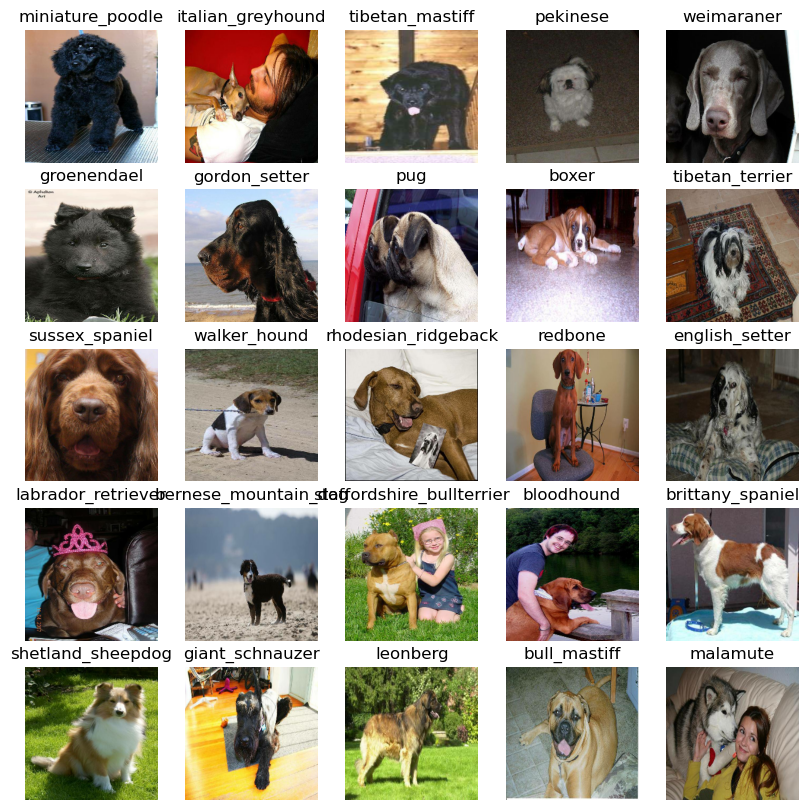

In [62]:
# Nows let's visualize the data in a training batch
train_images, train_labels = next(train_data.as_numpy_iterator()) # Convert the batch data to an iterator -> grab the next batch from the data that is 32
show_25_images(train_images, train_labels)

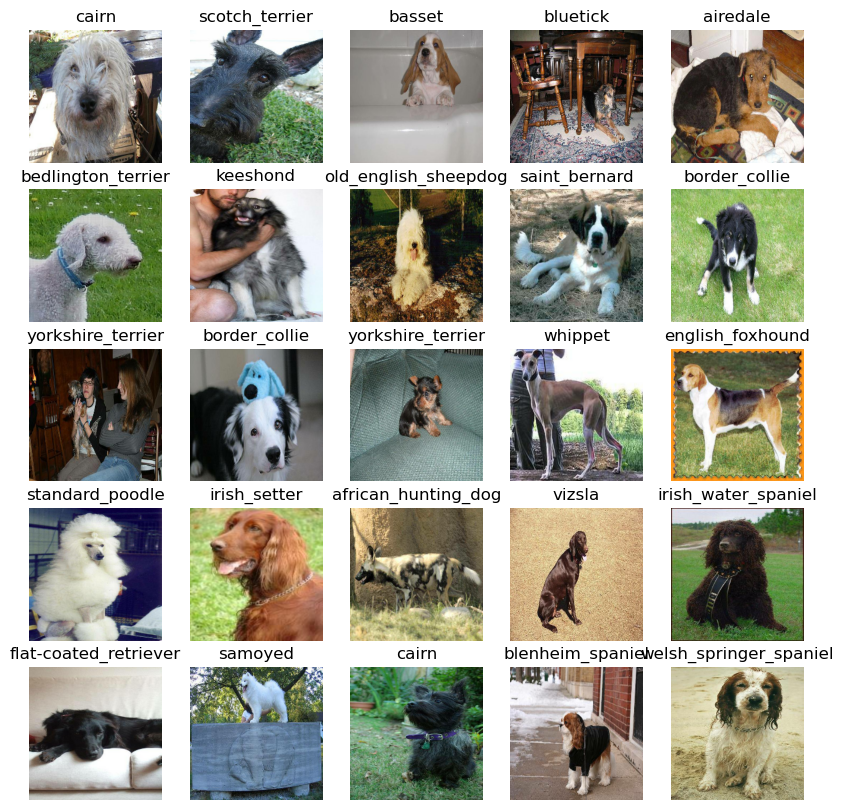

In [63]:
# Now let's visualize our validation set
val_images, val_labels = next(val_data.as_numpy_iterator())
show_25_images(val_images, val_labels)

![tensorflow workflow](./assets/images/unstructured-data-tesnorflow-workflow.png)

## **Building a model**

Before we build a model, there are few things we need to define:

- The `input` shape (our image shape, in the form of Tensors) to the model.
- The `output` shape (image labels, in the form of Tensors) of our model.
- The URL of the model we want to use: [From TensorFlow Hub/ Kaggle](https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/130-224-classification/1)

In [64]:
# Setup input shape to the model
INPUT_SHAPE = [None, IMG_SIZE, IMG_SIZE, 3] # Batch, height, width, colour_channels

# Setup ouyput shape of our model
OUTPUT_SHAPE = len(unique_breeds)

# Setup model URL from TensorFlow Hub
MODEL_URL = MODEL_URL = "https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/130-224-classification/1"

**Now we've have got our inputs, outputs and model to go. Let's put them into a `Keras deep learning model!`**

Knowing this, let's create a function:
- Takes the input shape, output shape and model we've chosen as parameters.
- Define the layers in a Keras model in sequential fashion (aka do this first, then that, then that).
- Compiles the model (says its should be evaluated and improved).
- Builds the model (tells the model the input shape it'll be getting).
- Returns the model

All of these steps can be found: [Here](https://www.tensorflow.org/guide/keras) and [also here about Sequential API](https://www.tensorflow.org/guide/keras/sequential_model)

**There are two ways to import a model:**
1. Either do as the kaggle ([eg. mobilenet_v2](https://www.kaggle.com/models/google/mobilenet-v2/tensorFlow2/130-224-classification/1?tfhub-redirect=true&select=saved_model.pb)) says which is fine (not used here because it caused compatibility issue)
2. Use `tf.keras.applications.MODEL_NAME` and you can names at [Keras](https://keras.io/api/applications/) and at [TensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/applications)

In [65]:
# Create a fuction which builds a Keras model

def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE, model_url=MODEL_URL):
    print("Building model with:", model_url)

    # Setup the model layers
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape[1:],
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False
    
    model = tf.keras.Sequential([
        base_model, # Layer 1 (pretrained feature extractor)
        tf.keras.layers.GlobalAveragePooling2D(),  # Layer 2
        tf.keras.layers.Dense(units=output_shape,
                              activation="softmax")  # Layer 3 (output layer)
    ])

    # Build the model
    model.build(input_shape) # Let the model know what kind of inputs it'll be getting (doesn't matter whether we give inputs or not cause its already defined in basline model)

    # Compile the model
    model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(), # Our model wants to reduce this (how wrong its guesses are)
        optimizer=tf.keras.optimizers.Adam(), # A friend telling our model how to improve its guesses
        metrics=["accuracy"] # We'd like this to go up
    )

    return model

<details>
<summary><b>Understanding create_model() — Full Breakdown</b></summary>

## The Three Parameters
- `input_shape = [None, 224, 224, 3]` — batch of images. None = flexible batch size, 224×224 = image size, 3 = RGB channels
- `output_shape = 120` — 120 dog breeds, 120 output probabilities
- `model_url` — leftover from old Hub version, unused in current code

---

## MobileNetV2
- A model Google pre-trained on 14 million ImageNet images
- `input_shape[1:]` — strips the None, passes just one image shape `[224, 224, 3]`
- `include_top=False` — removes Google's original 1000-category output layer, we add our own
- `weights="imagenet"` — loads pre-learned weights, no training from scratch
- `base_model.trainable = False` — freezes all MobileNetV2 weights ❄️, only our Dense layer trains

---

## Sequential — The Assembly Line

```
Input image [None, 224, 224, 3]
        ↓
MobileNetV2 (frozen ❄️)
→ outputs 7 × 7 × 1280 feature maps
        ↓
GlobalAveragePooling2D
→ collapses 7 × 7 × 1280 → flat [1280 numbers]
→ needed because Dense only accepts a flat 1D list
        ↓
Dense (120 neurons, softmax)
→ outputs 120 probabilities, highest = predicted breed
```

---

## Softmax
Takes raw scores → makes all positive → divides by total → probabilities that add up to 1.0

```
labrador:  e^3.2 = 24.5  →  24.5 / 29.0  =  0.84  → 84%
poodle:    e^1.1 =  3.0  →   3.0 / 29.0  =  0.10  → 10%
bulldog:   e^0.4 =  1.5  →   1.5 / 29.0  =  0.06  →  6%
                                                       ────
                                                       1.00 ✅
```

---

## model.build()
Finalizes weights in memory. Redundant in our version since MobileNetV2 already knows its input shape.

---

## model.compile()
- `loss` — CategoricalCrossentropy measures how wrong predictions are. Model tries to reduce this.
- `optimizer` — Adam figures out how to adjust weights to reduce loss.
- `metrics` — tracks accuracy for you to read during training, doesn't affect learning.

</details>

# Sequential vs Functional API
*Transfer Learning · TensorFlow 2*

---

**Two things, two different jobs:**
- `include_top=False` → **removes** MobileNetV2's original 1000-class output head entirely
- `base_model.trainable = False` → **freezes** all weights so ImageNet knowledge is preserved

If you unfreeze carelessly → catastrophic forgetting. Model doesn't predict new things, it just gets *bad* at dog breeds.

---

## Sequential — conveyor belt

Give Keras a list. It wires everything automatically, top to bottom. No control, but simple.  
Keras is lazy — `model.build(INPUT_SHAPE)` is needed to tell it the input size and initialize weights.

<details>
<summary>📄 Show code</summary>

```python
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,                                                      # feature extractor
    tf.keras.layers.GlobalAveragePooling2D(),                        # (7,7,1280) → (1280,)
    tf.keras.layers.Dense(OUTPUT_SHAPE, activation="softmax")        # (1280,) → 120 breeds
])

model.build(INPUT_SHAPE)    # tell Keras input size → initializes weights
model.compile(...)
```

</details>

---

## Functional — relay race

You pass data through each layer manually. `inputs` is just a placeholder describing the shape of data — not real data. `Layer()(x)` = create the layer + call it with x in one line.  
No `model.build()` needed — `tf.keras.Input()` already told Keras the input size upfront.

<details>
<summary>📄 Show code</summary>

```python
base_model.trainable = False

inputs  = tf.keras.Input(shape=INPUT_SHAPE)             # placeholder, describes shape of data

x       = base_model(inputs, training=False)            # training=False → keeps BatchNorm frozen too
x       = tf.keras.layers.GlobalAveragePooling2D()(x)   # Layer()(x) = create + call in one line
outputs = tf.keras.layers.Dense(OUTPUT_SHAPE, activation="softmax")(x)

model   = tf.keras.Model(inputs=inputs, outputs=outputs)  # seal the blueprint
model.compile(...)
```

</details>

---

## Quick comparison

| | Sequential | Functional |
|---|---|---|
| Wiring | Automatic | Manual — you control every handoff |
| Input shape | `model.build(input_shape)` | `tf.keras.Input(shape=...)` |
| Flexibility | Limited | Full control |
| Use for | Quick prototyping | Real projects, fine-tuning |

**Use Functional** for this project — fine-tuning later is cleaner, `training=False` is explicit, and it's what every real codebase uses. You already wrote it in `create_model()`, it just had no name.

<details>
  <summary><b>Why this model cell instead of the old Hub version?</b></summary>

  We are using this version because it works with the TensorFlow and Keras stack currently installed in your notebook.

  The old `hub.KerasLayer(...)` approach failed because your environment treated it as an incompatible layer type, so `Sequential([...])` rejected it.

  This version uses `tf.keras.applications.MobileNetV2`, which is a native Keras model, so it plugs into `Sequential` cleanly.

  It also keeps the transfer-learning idea intact:
  - the pretrained base learns image features
  - `GlobalAveragePooling2D` compresses those features
  - the final `Dense` layer predicts the 120 dog breeds

  In short: this is the same learning idea, but with a layer type your current environment actually accepts.
</details>

<details>
  <summary><b>Show old code and corrected code</b></summary>

  ### Old version

  ```python
  def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE, model_url=MODEL_URL):
      print("Building model with: ", model_url)

      # Setup the model layers
      model = tf.keras.Sequential([
          hub.KerasLayer(model_url, trainable=False), # Layer 1 (input layer)
          tf.keras.layers.Dense(units=output_shape,
                                activation="softmax")  # Layer 2 (output layer)
      ])

      # Build the model
      model.build(input_shape) # Let the model know what kind of inputs it'll be getting

      # Compile the model
      model.compile(
          loss=tf.keras.losses.CategoricalCrossentropy(),
          optimizer=tf.keras.optimizers.Adam(),
          metrics=["accuracy"]
      )

      return model
  ```

  ### Corrected version

  ```python
  def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE, model_url=MODEL_URL):
      print("Building model with: ", model_url)

      # Setup the model layers
      base_model = tf.keras.applications.MobileNetV2(
          input_shape=input_shape[1:],
          include_top=False,
          weights="imagenet"
      )
      base_model.trainable = False

      model = tf.keras.Sequential([
          base_model, # Layer 1 (pretrained feature extractor)
          tf.keras.layers.GlobalAveragePooling2D(),
          tf.keras.layers.Dense(units=output_shape,
                                activation="softmax")  # Layer 2 (output layer)
      ])

      # Build the model
      model.build(input_shape) # Let the model know what kind of inputs it'll be getting

      # Compile the model
      model.compile(
          loss=tf.keras.losses.CategoricalCrossentropy(),
          optimizer=tf.keras.optimizers.Adam(),
          metrics=["accuracy"]
      )

      return model
  ```
</details>

In [66]:
model = create_model()
model.summary()

Building model with: https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/130-224-classification/1
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 120)               153720    
                                                                 
Total params: 2411704 (9.20 MB)
Trainable params: 153720 (600.47 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________



---

### **Creating Callbacks**

**Callbacks** are **helper functions** a model can use during **training** to do such things as **save its progress**, **track its performance**, **adjust learning behavior**, or **stop training when it’s no longer improving**.

We’ll create multiple callbacks:

* one for **TensorBoard** (to track our model’s progress),
* one for **early stopping** (to prevent overtraining),
* and optionally others to **improve training stability and save the best model**.

---

### **TensorBoard Callback**

To setup a TensorBoard callback, we need to do 3 things:

1. Load the TensorBoard notebook extension ✅
2. Create a TensorBoard callback which is able to save logs to a directory and pass it to our model’s `fit()` function. ✅
3. Visualize our model’s training logs with the `%tensorboard` magic function (we’ll do this after model training).

---

### 🔧 (Added — clean extension, no disruption)

Along with TensorBoard, we can also include:

* **EarlyStopping** → stops training when validation stops improving
* **ReduceLROnPlateau** → lowers learning rate when progress slows
* **ModelCheckpoint** → saves the best version of the model

👉 These don’t change the model itself, only **how it trains**

---

In [67]:
# Load TensorBoard notebook extention
%load_ext tensorboard

In [68]:
import datetime
import os

# Create a Function to build a TensorBoard callback
def create_tensorboard_callbacks():
    # Create a log directory for storing TensorBoard logs
    logdir = os.path.join(str(LOG_DIR), datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
    os.makedirs(logdir, exist_ok=True)
    return tf.keras.callbacks.TensorBoard(log_dir=logdir)

### **Early Stopping Callback**

Early stopping is a technique used to prevent **overfitting** by stopping training when the model’s performance on validation data stops improving.

Instead of training for a fixed number of epochs, the model monitors a chosen metric (commonly `val_loss`) and stops if no improvement is seen for a specified number of epochs (`patience`).

👉 This helps:
- Avoid unnecessary training  
- Prevent the model from memorizing training data  
- Save time and computational resources  

📌 Note:
- `val_loss` is preferred over `val_accuracy` because it provides a smoother and more sensitive signal of learning progress.
- `restore_best_weights=True` ensures the model keeps the best-performing version, not just the final one.

🔗 Official documentation:  
https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping

In [69]:
def create_callbacks():
    return [
        create_tensorboard_callbacks(), # Track training logs
        
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", # Stop when validation stops improving (better than "val_accuracy")
            patience=3,
            restore_best_weights=True
        ),
        
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", # Reduce LR when stuck
            factor=0.2,
            patience=2
        ),
        
        tf.keras.callbacks.ModelCheckpoint(
            "best_model.keras",  # Save the best model
            save_best_only=True
        )
    ]

<details>
<summary><strong>Why we use create_callbacks() instead of a single EarlyStopping(old)</strong></summary>

<br>

### 🔹 Old approach (instructor)

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3
    )

- Handles only **one task** → stopping training  
- Uses **validation accuracy**, which can fluctuate  
- Does **not restore best weights**  
- No learning rate control  
- No model saving  

---

### 🔹 New approach (create_callbacks)

    def create_callbacks():
        return [
            create_tensorboard_callback(),
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.2,
                patience=2
            ),
            tf.keras.callbacks.ModelCheckpoint(
                "best_model.keras",
                save_best_only=True
            )
        ]

- **TensorBoard** → track training visually  
- **EarlyStopping** → stop at the right time  
- **ReduceLROnPlateau** → lower learning rate when stuck  
- **ModelCheckpoint** → save best model  

👉 This gives **control over the full training process**, not just stopping.

---

### 🔹 Why `val_loss` instead of `val_accuracy`

**val_accuracy**
- Measures correct predictions  
- Can jump randomly  
- Not sensitive to small improvements  

**val_loss**
- Measures how wrong predictions are  
- Smooth and continuous  
- Better signal for optimization  

👉 Loss is what the model is actually minimizing  
👉 Accuracy is just a result metric  

---

### 🔹 What is `val_loss`?

- `loss` → error on training data  
- `val_loss` → error on validation (unseen) data  

If:
- `loss ↓` but `val_loss ↑` → overfitting  
- `val_loss ↓` → model generalizing well  

---

### 🔹 How to use

    callbacks = create_callbacks()

    model.fit(
        train_data,
        epochs=NUM_EPOCHS,
        validation_data=val_data,
        callbacks=callbacks
    )

---

### 🔹 Final idea

Old:
> Stop when accuracy stops improving  

New:
> Track + adjust + save + stop training intelligently  

</details>

## **Training a model (on subset of data)**

Our first model is only going to train on **1000 images**, to make sure everything is working 

In [70]:
# Defining the number of epochs for the model
# ipywidgets is already imported in this notebook as `widgets`.
from IPython.display import display

NUM_EPOCHS = globals().get("NUM_EPOCHS", 100)
num_epochs_slider = widgets.IntSlider(
    value=NUM_EPOCHS,
    min=10,
    max=100,
    step=1,
    description="NUM_EPOCHS",
    continuous_update=False,
)
num_epochs_label = widgets.Label(value=f"NUM_EPOCHS = {NUM_EPOCHS}")

def on_num_epochs_change(change):
    global NUM_EPOCHS
    NUM_EPOCHS = change["new"]
    num_epochs_label.value = f"NUM_EPOCHS = {NUM_EPOCHS}"

num_epochs_slider.observe(on_num_epochs_change, names="value")
display(num_epochs_slider, num_epochs_label)

IntSlider(value=100, continuous_update=False, description='NUM_EPOCHS', min=10)

Label(value='NUM_EPOCHS = 100')

In [71]:
# Check to make sure we are still running on a GPU
print("GPU", "available (YES!!!!!!)" if tf.config.list_physical_devices("GPU") else "Not available :(")

GPU available (YES!!!!!!)


**Let's create a function which trains a model.**

* Create a model using `create_model()`
* Setup a TensorBoard claaback using `create_tensorboard_callback()`
* Call a `fit()` function on our model passing it the **training data**, **validation data**, **number of epochs** to train for (`NUM_EPOCHS`) and the callbacks we'd like to use
* Return the model

In [72]:
# Build a model to train and return a trained model

def train_model():
    """
    Train a given model and returns the trained version.
    """
    
    # Create a model
    model = create_model()
    
    # Create a new TensorBoard session everytime we train a model
    tensorboard = create_callbacks()
    
    # Fit the model to the data passing it the callbacks we created
    model.fit(x=train_data,
              epochs=NUM_EPOCHS,
              validation_data=val_data,
              callbacks=list(tensorboard))
    
    # return the fitted model
    return model

In [73]:
# Fit the model to the data
model = train_model()

Building model with: https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/130-224-classification/1
Epoch 1/100


2026-05-06 18:22:22.949409: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1778091745.011520     554 service.cc:145] XLA service 0x7dd9d9175180 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778091745.011683     554 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-05-06 18:22:25.048306: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778091745.276896     554 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 [==============================] - 52s 482ms/step - loss: 4.4495 - accuracy: 0.0887 - val_loss: 3.5514 - val_accuracy: 0.2200 - lr: 0.0010
Epoch 2/100
25/25 [==============================] - 4s 177ms/step - loss: 1.9373 - accuracy: 0.6662 - val_loss: 2.4067 - val_accuracy: 0.4600 - lr: 0.0010
Epoch 3/100
25/25 [==============================] - 5s 189ms/step - loss: 0.8776 - accuracy: 0.9112 - val_loss: 1.9139 - val_accuracy: 0.5650 - lr: 0.0010
Epoch 4/100
25/25 [==============================] - 4s 170ms/step - loss: 0.4737 - accuracy: 0.9737 - val_loss: 1.7512 - val_accuracy: 0.5600 - lr: 0.0010
Epoch 5/100
25/25 [==============================] - 5s 217ms/step - loss: 0.2941 - accuracy: 0.9912 - val_loss: 1.6387 - val_accuracy: 0.5950 - lr: 0.0010
Epoch 6/100
25/25 [==============================] - 5s 176ms/step - loss: 0.2044 - accuracy: 0.9950 - val_loss: 1.5963 - val_accuracy: 0.6100 - lr: 0.0010
Epoch 7/100
25/25 [==============================] - 5s 183ms/step - loss: 

**Question:**

Its looks like our model is overfitting because it's performing far better on the training dataset than on validation dataset, what are some ways to prevent model from overfitting in deep learning neural network?

**Note:** Overfitting to begin with is a good thing! Its means our model is learning.

**Answer:**

**Preventing Overfitting in Deep Learning**

---

<details>
<summary><b>🧠 What is Overfitting?</b></summary>

<br>

Think of a student who **memorizes the textbook word-for-word** instead of understanding the concepts.

- They **ace the practice test** (training data)
- But **fail the real exam** (validation data) — because questions are phrased differently

Your model does the same: it learns the training images *too specifically*, including their noise and quirks.

```
Training accuracy:   High ✅
Validation accuracy: Low  ❌

→ Model memorized, not generalized
```

> **The goal is not a model that knows the training data.**
> **The goal is a model that understands dogs.**

</details>

---

<details>
<summary><b>📦 Fix 1 — More Data</b></summary>

<br>

**The single most effective fix.** More variety = harder to memorize.

- You're currently training on **1000 images**
- The more images the model sees, the harder it is to memorize any specific pattern
- Jumping to the full dataset is the first thing you should try

> **More data = more generalization = less overfitting**

</details>

---

<details>
<summary><b>🔄 Fix 2 — Data Augmentation</b></summary>

<br>

**Can't get more data? Fake it.**

Randomly transform images during training — flip, rotate, zoom, brighten. The model sees a *slightly different* version of the same image each epoch.

**Why it works:** Forces the model to learn *features* (ears, snout, fur texture), not exact pixel positions.

```python
augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.2)
], name="data_augmentation")
```

> **Analogy:** Studying the same notes but with different lighting, fonts, and page order each time — you learn the *content*, not the format.

</details>

---

<details>
<summary><b>🎲 Fix 3 — Dropout</b></summary>

<br>

**Randomly "turn off" a percentage of neurons during each training step.**

```python
tf.keras.layers.Dropout(rate=0.5)  # 50% of neurons disabled randomly each step
```

**Why it works:**
- Network can't rely on any single neuron or path
- Forces it to build redundant, distributed representations
- At inference time, all neurons are active (and outputs are scaled)

> **Analogy:** Studying with random pages torn out each session — you learn the material more robustly because you can't depend on one specific thing.

**Common rates:**
| Layer Type | Typical Dropout Rate |
|---|---|
| Dense (output head) | 0.3 – 0.5 |
| Convolutional | 0.1 – 0.3 |
| After feature extractor | 0.2 – 0.5 |

</details>

---

<details>
<summary><b>🛑 Fix 4 — Early Stopping</b></summary>

<br>

**Stop training the moment `val_loss` stops improving.**

```python
tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,                  # Wait 3 epochs before stopping
    restore_best_weights=True    # Rewind to the best checkpoint
)
```

**What it prevents:**
- Model training past the point of generalization
- Wasted compute on epochs that only make overfitting worse

**Reading the signal:**

```
loss ↓  but  val_loss ↑   →  Overfitting is happening
val_loss ↓               →  Model is still generalizing
val_loss plateaus        →  EarlyStopping kicks in
```

> ✅ **You already have this in your callbacks. It's working for you.**

</details>

---

<details>
<summary><b>⚖️ Fix 5 — L2 Regularization (Weight Decay)</b></summary>

<br>

**Penalizes large weights during training.**

Adds a small penalty to the loss for every weight that grows too large. Forces the model to keep weights small and spread out rather than over-specializing.

```python
tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_regularizer=tf.keras.regularizers.l2(0.01)
)
```

**Intuition:**

| Without Regularization | With L2 Regularization |
|---|---|
| A few neurons dominate | Weights are small and balanced |
| Memorizes training data | Generalizes better |
| Sharp decision boundaries | Smooth decision boundaries |

> **Best used on the Dense output head**, not the frozen feature extractor (MobileNet already handles its own weights).

</details>

---

<details>
<summary><b>📊 Quick Reference — Overfitting Diagnosis</b></summary>

<br>

```
Model behaviour          →  What it means
─────────────────────────────────────────────────────
train_acc high           
val_acc low              →  Overfitting 
─────────────────────────────────────────────────────
train_acc low            
val_acc low              →  Underfitting (model not learning)
─────────────────────────────────────────────────────
train_acc high           
val_acc high             →  Well generalized ✅
─────────────────────────────────────────────────────
train_acc ≈ val_acc      
both low                 →  Need more model capacity
```

</details>

---

### **Checking the TensorBoard logs**

The TensorBoard magic function (`%tensorboard`) will access the logs directory we created earlier and visualize its contents.

In [74]:
import ipywidgets as widgets
print(widgets.__version__)

8.1.8


In [75]:
logdir = str(LOG_DIR)
%tensorboard --logdir $logdir

Reusing TensorBoard on port 6006 (pid 9882), started 3 days, 3:30:21 ago. (Use '!kill 9882' to kill it.)

**Watch the above output in Google Collab**

For reference it looks like

![](./assets/images/epoch_accuracy.png)

---

![](./assets/images/epoch_loss.png)

---

![](./assets/images/evaluation_accuracy_vs_iterations.png)

---

![](./assets/images/evaluation_loss_vs_iterations.png)

---

![Overview](./assets/images/TensorBoard.png)

---

## **Making and evaluating predictions using a trained model**

In [76]:
val_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [77]:
# Make predictions on the validation data (not used to train on)

predictions = model.predict(val_data,
                            verbose=1)
predictions

7/7 [==============================] - 10s 251ms/step


array([[2.9322342e-04, 4.1693792e-04, 1.3310817e-04, ..., 4.8095622e-05,
        2.1634076e-05, 1.5785432e-03],
       [2.5466271e-04, 3.9373591e-04, 5.2455477e-03, ..., 8.5906786e-06,
        1.7197611e-03, 2.5105053e-05],
       [7.8848961e-06, 3.0237791e-04, 1.6984282e-04, ..., 2.2153405e-05,
        3.4316803e-05, 2.2063293e-03],
       ...,
       [3.3249056e-05, 2.4959014e-04, 6.5341934e-05, ..., 8.1010345e-05,
        7.9702659e-06, 1.7999347e-04],
       [3.4709455e-04, 2.9644223e-05, 2.5498259e-04, ..., 1.1200727e-05,
        2.6542707e-06, 6.9303424e-03],
       [1.4599503e-04, 5.0061344e-06, 7.5216230e-04, ..., 7.6460262e-04,
        2.6383984e-04, 5.3469697e-04]], dtype=float32)

In [78]:
predictions.shape # 200 rows with each having 120 probabilites which sums to total of 1

(200, 120)

In [79]:
len(predictions[0])

120

In [80]:
np.sum(predictions[0])

0.9999998

In [81]:
len(y_val)  # labels

200

In [82]:
len(unique_breeds)

120

In [83]:
# First predictions
index = 1
print(predictions[index])
print(f"Max value (probability of predictions): {np.max(predictions[index])}") # confidence prediction
print(f"Sum: {np.sum(predictions[index])}")
print(f"Max index: {np.argmax(predictions[index])}")
print(f"Predicted Label: {unique_breeds[np.argmax(predictions[index])]}")

[2.5466271e-04 3.9373591e-04 5.2455477e-03 4.6312157e-03 2.4080964e-06
 3.7157110e-07 1.2709785e-04 6.3180196e-04 2.1353974e-04 3.5324001e-07
 2.1557227e-05 5.0840328e-05 2.3780856e-06 1.6695977e-06 5.5554923e-05
 8.4098334e-05 1.6830940e-04 6.3556537e-05 5.6706936e-06 3.9767889e-05
 7.5483025e-05 1.5168002e-06 8.0201180e-06 2.8853042e-06 3.5256542e-06
 8.9892131e-07 2.8001118e-04 1.4394199e-03 3.0825664e-03 3.3650020e-04
 4.5983396e-07 7.1384120e-06 6.0895947e-04 7.0477188e-05 1.6532536e-03
 1.6492120e-06 4.8401274e-05 3.4361519e-04 2.1689980e-04 3.9457765e-07
 1.0646432e-05 3.3237327e-05 2.4700153e-06 1.8506689e-06 1.2115318e-03
 1.7792050e-05 3.5625271e-05 8.6075517e-05 6.7209285e-03 3.7204215e-06
 2.7793163e-05 3.0190460e-05 4.9283117e-06 2.9968674e-06 2.1867864e-03
 5.4476212e-04 6.0613223e-05 4.5335996e-01 3.2257009e-04 1.1112514e-02
 6.4672669e-04 1.5681248e-08 3.0528236e-06 1.9329063e-05 1.2408978e-03
 9.7821840e-07 9.2294695e-06 6.8495923e-05 8.7770382e-03 5.0881237e-08
 1.404

In [84]:
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

**Having the above functionality is great but we want it to be able to do it at scale.**

And it would be even better if we could see the image the prediction is being made on.

**Note:** Predictions probabilites are also knows as confidence levels.

In [85]:
# Turn predictions probabilities into their respective labels (easier to understand)
def get_pred_label(prediction_probabilities):
    """
    Turns an array of predictions probabilites into a label
    """
    
    return unique_breeds[np.argmax(prediction_probabilities)]


# get a predicted label based on an array of predictions probabilities
pred_label = get_pred_label(predictions[81])
pred_label

'chihuahua'

**Now since our validation is still in a batch datatset, we'll have to unbatchify it to make predictions on the validation images and then compare those predictions to the validation labels(Truth labels).**

In [86]:
val_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [87]:
# Create a function to unbatch a batch dataset
def unbatchify(data):
    """
    Takes a batched dataset of (image, label) Tensors and returns seperate arrays
    """
    images = []
    labels = []
    # Loop through unbatched data
    for image, label in data.unbatch().as_numpy_iterator():
        images.append(image)
        labels.append(unique_breeds[np.argmax(label)])
        
    return images, labels

# Untachify the validation data
val_images, val_labels = unbatchify(val_data)
val_images[0], val_labels[0]


2026-05-06 18:25:49.713595: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(array([[[0.29599646, 0.43284872, 0.3056691 ],
         [0.26635826, 0.32996926, 0.22846507],
         [0.31428418, 0.27701408, 0.22934894],
         ...,
         [0.77614343, 0.82320225, 0.8101595 ],
         [0.81291157, 0.8285351 , 0.8406944 ],
         [0.8209297 , 0.8263737 , 0.8423668 ]],
 
        [[0.2344871 , 0.31603682, 0.19543913],
         [0.3414841 , 0.36560842, 0.27241898],
         [0.45016077, 0.40117094, 0.33964607],
         ...,
         [0.7663987 , 0.8134138 , 0.81350833],
         [0.7304248 , 0.75012016, 0.76590735],
         [0.74518913, 0.76002574, 0.7830809 ]],
 
        [[0.30157745, 0.3082587 , 0.21018331],
         [0.2905954 , 0.27066195, 0.18401104],
         [0.4138316 , 0.36170745, 0.2964005 ],
         ...,
         [0.79871625, 0.8418535 , 0.8606443 ],
         [0.7957738 , 0.82859945, 0.8605655 ],
         [0.75181633, 0.77904975, 0.8155256 ]],
 
        ...,
 
        [[0.9746779 , 0.9878955 , 0.9342279 ],
         [0.99153054, 0.99772066, 0.94278

* `val_images` → list of 200 images
* `val_labels` → list of 200 breed name strings

- `val_images` = [🐕img, 🐩img, 🦮img, ...]   ← just images
- `val_labels` = ["beagle", "poodle", "husky", ...]  ← just names

In [88]:
get_pred_label(val_labels[0]), get_pred_label(predictions[0])

('affenpinscher', 'lhasa')

**Now we got ways to get:**
* Prediction labels
* Validation labels (truth labels)
* Validation images

Let's make some fucntions to make these all a bit more visualize.

**We'll create a functioin which**
* Takes an array of predictions probabilities and arrays of truth labels and an array of image and an integer. ✅
* Convert the predictions probabilities to predicted label. ✅
* Plot the predicte label, it's predicted probability, the truth label and the target image on a single plot ✅

In [89]:
def plot_pred(prediction_probabilities, labels, images, n=1):
    """
    View the prediction, ground truth and image for sample n
    """
    
    pred_prob, true_label, image = prediction_probabilities[n], labels[n], images[n]
    
    # Get the pred label
    pred_label = get_pred_label(pred_prob)
    
    # Plot image and remove ticks
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
    
    # Change the colour of the title on if the prediction is right or wrong
    if pred_label == true_label:
        color = "blue"
    else:
        color = "orange"
    
    # Change the plot title to be predicted, probability of prediction and truth label
    plt.title("{} {:2.0f}% {}".format(
        pred_label,
        np.max(pred_prob)*100,
        true_label
        ),
        color=color
)

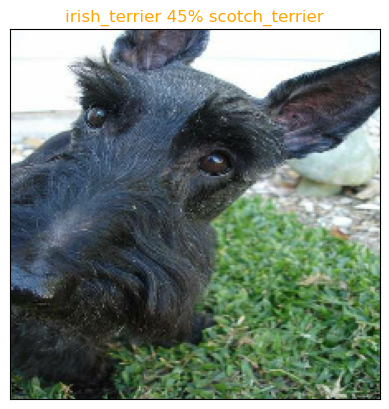

In [90]:
plot_pred(prediction_probabilities=predictions,
          labels=val_labels,
          images=val_images)

# Correct -> blue, wrong -> yellow

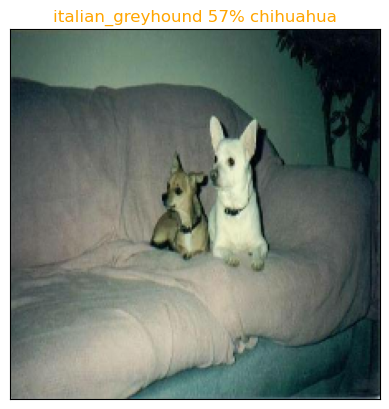

In [91]:
plot_pred(prediction_probabilities=predictions,
          labels=val_labels,
          images=val_images,
          n=104)
# Correct -> blue, wrong -> yellow

Now we've got one fuctiont to visualize our model top predictions, let's make an another to view our models top 10 predictions.

**The function will:**
* Take an input of prediction probability array, a ground truth array and an integer. ✅`
* Find the predictive label using `get_pred_labels()` ✅
* Find the top 10:
  * Prediction probabilities indexes ✅
  * Prediction probabilities values ✅
  * Prediction labels ✅
* Plot the top 10 prediction probability and labels, colouring the true label `green`

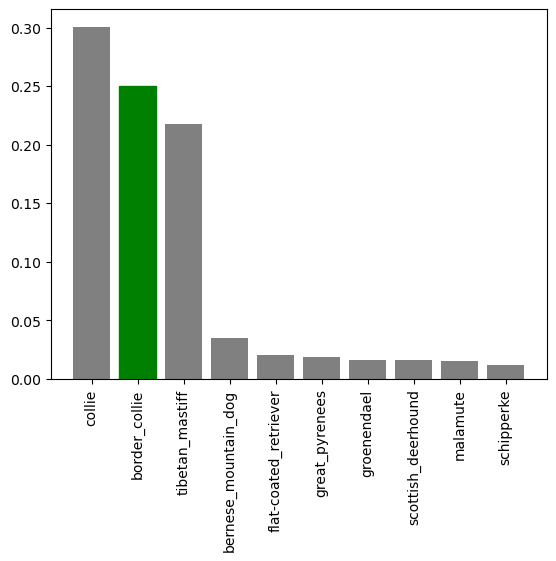

In [92]:
def plot_pred_conf(prediction_probabilities, labels, n=1):  # plot prediction confidence
    """
    Plus the top 10 highest prediction confidences along with truth label for sample n.
    """
    pred_prob, true_labels = prediction_probabilities[n], labels[n]
    
    # Get the predicted label
    pred_label = get_pred_label(pred_prob)
    
    # Find the top 10 prediction confidence indexes
    top_10_pred_indexes = pred_prob.argsort()[-10:][::-1]
    
    # Find the top 10 prediction confidence values
    top_10_pred_values = pred_prob[top_10_pred_indexes]
    
    # Find the top 10 prediction labels
    top_10_pred_labels = unique_breeds[top_10_pred_indexes]
    
    # Setup plot
    top_plot = plt.bar(x=np.arange(len(top_10_pred_labels)),
                       height=top_10_pred_values,
                       color="grey")
    plt.xticks(np.arange(len(top_10_pred_labels)), # the numbers: [0,1,2,...,9]
               labels=top_10_pred_labels,          # the name cards: ["labrador", "poodle", ...]
               rotation="vertical")                # tilt the names so they don't overlap
    
    # Change the color of true label
    if np.isin(true_labels, top_10_pred_labels):  # is that inside this
        top_plot[np.argmax(top_10_pred_labels==true_labels)].set_color("green")  # np.argmax() finds the index of True 
    else:
        pass
    
    
plot_pred_conf(prediction_probabilities=predictions,
               labels=val_labels,
               n=9)

In [93]:
predictions[0]

array([2.93223420e-04, 4.16937924e-04, 1.33108173e-04, 8.20284185e-05,
       1.04041916e-04, 6.51183218e-05, 2.34920345e-03, 1.36436924e-04,
       7.22459517e-04, 6.87406209e-05, 1.40450356e-04, 1.56854425e-04,
       1.08503467e-04, 7.44773279e-05, 6.66387859e-05, 5.70062439e-05,
       5.86214719e-06, 1.04565537e-02, 1.29636146e-05, 2.42158931e-05,
       5.19559078e-04, 1.64140161e-04, 2.07578414e-05, 1.30554559e-04,
       5.96197424e-06, 2.53324833e-05, 2.63093435e-03, 6.66162887e-05,
       2.18121248e-04, 9.31775721e-05, 2.59968620e-05, 4.92610270e-04,
       7.02849065e-05, 6.43022431e-05, 8.16685788e-05, 3.65414843e-03,
       2.01169642e-05, 1.31516717e-05, 1.01568949e-05, 1.43426269e-05,
       7.96150300e-04, 4.56902490e-06, 4.58618160e-06, 1.70531275e-05,
       1.01848353e-04, 3.85857456e-05, 7.87022202e-07, 2.38132838e-04,
       3.34008218e-04, 1.38424613e-04, 3.09372217e-06, 3.19335377e-04,
       1.36967131e-03, 8.56254846e-05, 5.61907473e-06, 2.77485037e-06,
      

In [94]:
predictions[0].argsort()[-10:]

array([ 68, 106,  17, 116,  73,  82, 103,  59, 109,  70])

In [95]:
# Top 10 predictions indexes
predictions[0].argsort()[-10:][::-1]  # In ascending order with respect to index

array([ 70, 109,  59, 103,  82,  73, 116,  17, 106,  68])

In [96]:
predictions[0][predictions[0].argsort()[-10:][::-1]]

array([0.65393525, 0.07815498, 0.05525447, 0.05143639, 0.0408449 ,
       0.03474281, 0.03054746, 0.01045655, 0.00461722, 0.00383103],
      dtype=float32)

In [97]:
predictions[0].max()

0.65393525

In [98]:
unique_breeds[predictions[0].argsort()[-10:][::-1]]

array(['lhasa', 'tibetan_terrier', 'irish_wolfhound',
       'soft-coated_wheaten_terrier', 'old_english_sheepdog',
       'maltese_dog', 'west_highland_white_terrier', 'border_terrier',
       'standard_schnauzer', 'lakeland_terrier'], dtype=object)

**Now we've got some functions to help us visualize our predictions and evaluate our model, let's check out a few.**

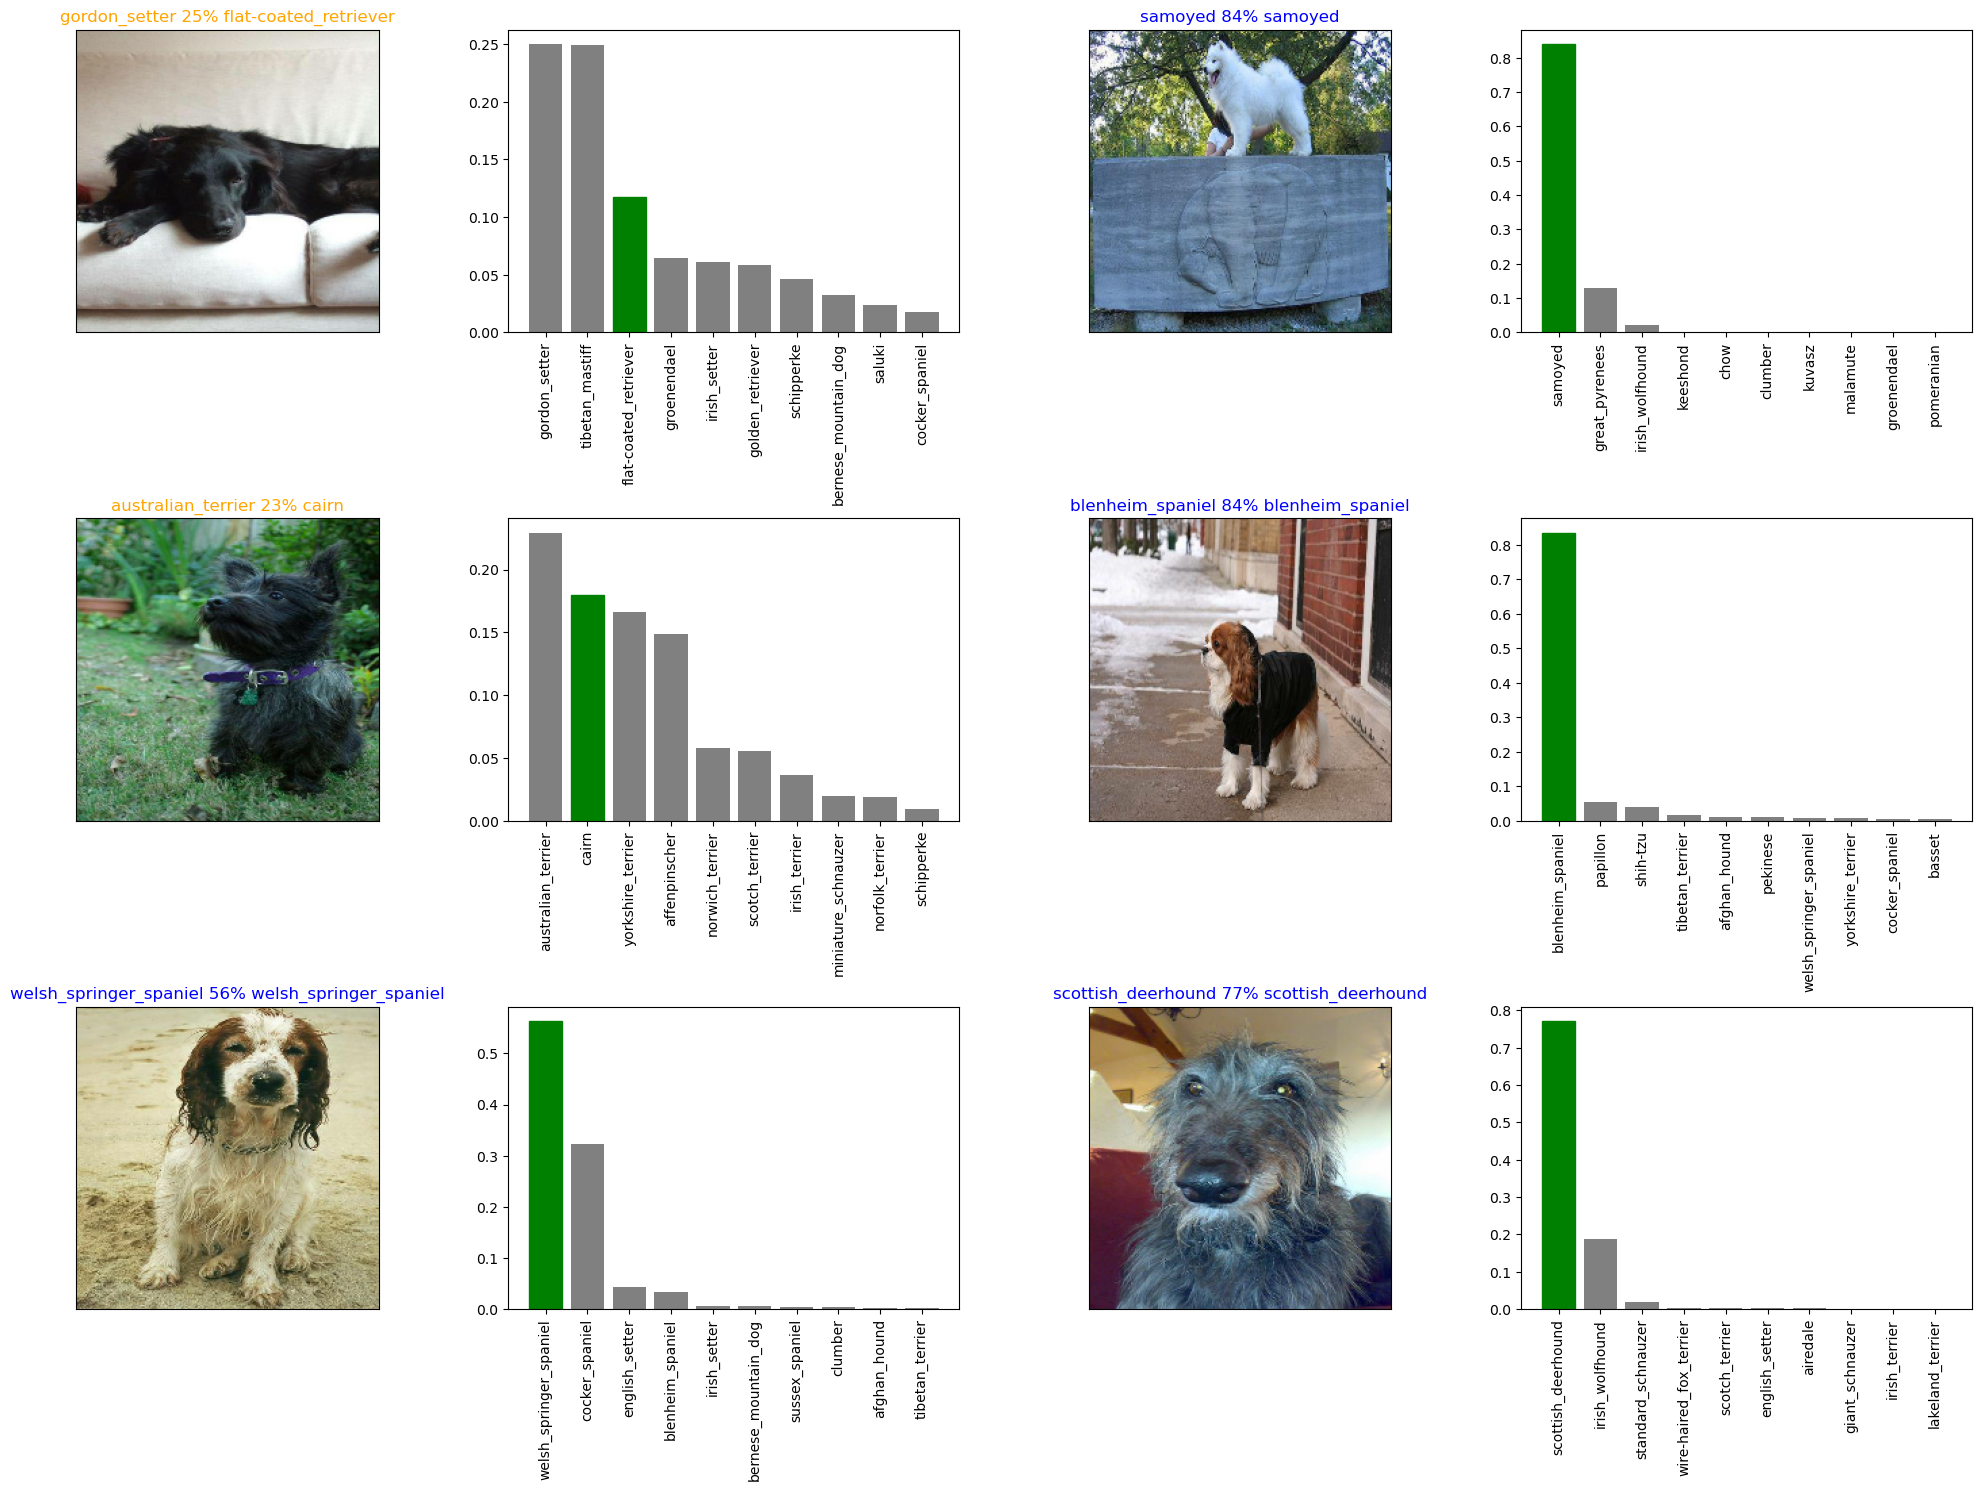

In [99]:
# Let's checkout out a few predictions and their different values
i_multiplier = 20
num_rows = 3
num_cols = 2
num_images = num_rows*num_cols
plt.figure(figsize=(10*num_cols, 5*num_rows))  # width -> cols, height -> rows
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1) # (rows, columns, cell number)
    plot_pred(prediction_probabilities=predictions,
              labels=val_labels,
              images=val_images,
              n=i+i_multiplier) # n=i+i_multiplier is just the image index. Eg. Starting from dog #20, then #21, then #22 and so on.
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_pred_conf(prediction_probabilities=predictions,
                   labels=val_labels,
                   n=i+i_multiplier)
plt.tight_layout(h_pad=1.0)
plt.show()


# [Image | Conf]  [Image | Conf]
# [Image | Conf]  [Image | Conf]
# [Image | Conf]  [Image | Conf]

# Iteration 0:
# [1] image
# [2] confidence

# Iteration 1:
# [3] image
# [4] confidence

# ...

**Challange:** How would you create a confusion matrix with our models predictions and true labels?


## **Confusion Matrix**


In **TensorFlow**, you build it with `tf.math.confusion_matrix(...)`, but it only works correctly when both inputs are **class IDs** (integers like 0, 1, 2...), not probabilities

> A confusion matrix is a grid that shows every combination of "what the true breed was" vs "what the model predicted."

- **Rows** = True class (actual answer)
- **Columns** = Predicted class (model's guess)
- **Each cell** = how many times that (true, predicted) pair happened

If the model is perfect → all numbers sit on the diagonal (true = predicted every time).

In [100]:
y_val

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False,  True,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [101]:
np.stack(y_val)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [102]:
# Confusion matrix (counts + row-normalization percentages)

# 1.) Predictions (probabilities -> class IDs)
y_preds_probs = model.predict(val_data, verbose=0)
y_preds = np.argmax(y_preds_probs, axis=1)

# 2.) True labels -> class IDs (works only if y_val is a list/array of one-hot boolean vectors)
y_true = np.argmax(np.stack(y_val), axis=1)

y_preds, y_true

(array([ 70,  57,   8,  17,   3,  10,  62,  82,  92,  33, 119,  52,  75,
        117,  39,  76,  56,   2,  44,  58,  50,  94,   6,  13, 115,  97,
         65,  26,  27,  37,  35, 113,  39,  96,  71,  71, 115,  75,  74,
         67,  67,  68,  39,  33, 110,  54,  21,  76, 110,  84, 104,  89,
         79,  88,  10,   0,  17,  99,  28,  67,  76,   6,   1,  75,  64,
         26,   7,   0,  94, 119,  74,  78,  15,  84,  90,   3,  34,  54,
         72,  31,  60,  29,  85,  75,  34, 101,  78,  93,  79,  86,  39,
         87,  29,  92,  71,  57,  33,  42,  26,  51,  14,  11,   6,  11,
         60, 104, 119, 100,  18,  25, 110,   9,  36, 119,  93,  94,  21,
         40,  85,  28,   9,  95,  67,  26,  97,  81,   6,  35,  33,  75,
         59,  32,  11,  64, 115,  96,  57,  67,  49,   4,   0,  64,  94,
        110,   1,  97, 115,   7,  32,  21,  77,  83,  94,   8,  98,  28,
        117,   1,  46,   0, 110,  13,  10,  11,   2,  61,  10,   1,  31,
         87,  95,   7,  93,  34,  11,  82,  29,  70

In [103]:
# 3.) Confusion Matrix (counts occurance of each class)

num_classes = 120

cm = tf.math.confusion_matrix(
    labels=y_true,
    predictions=y_preds,
    num_classes=num_classes
).numpy() # converting Tensor object -> NumPy object

cm

# Builds 120x120 grid
# Cell [i][j] = how many times true=i and predicted=j
# Diagonal = correct predictions
# Off diagonal = mistakes

# pred_0  pred_1  pred_2
# true_0 [  0,     0,     0  ]
# true_1 [  0,     0,     0  ]
# true_2 [  0,     0,     0  ]


array([[2, 0, 0, ..., 0, 0, 0],
       [0, 4, 0, ..., 0, 0, 0],
       [0, 0, 2, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 2, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1]], dtype=int32)

In [104]:
# 4.) Row normalization Confusion Matrix (per-class percentage)
with np.errstate(all='ignore'):
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

cm_norm

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.66666667, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.33333333]])

In [105]:
# 5.) What if a breed has 0 images in validation? Then that row sum = 0.
cm_norm = np.nan_to_num(cm_norm)
cm_norm


#                  ← Predicted (X axis) →
#               breed_0  breed_1  breed_2

#        breed_0 [  80,     15,      5  ]
#   ↑    breed_1 [   2,      8,      0  ]
# True   breed_2 [  10,      3,     47  ]
# (Y)

# Go to row 0 (true = breed 0), column 1 (predicted = breed 1)
# Eg. cm[0][1] = 15

# Means: 15 images that were actually breed 0
#        got wrongly predicted as breed 1

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.66666667, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.33333333]])

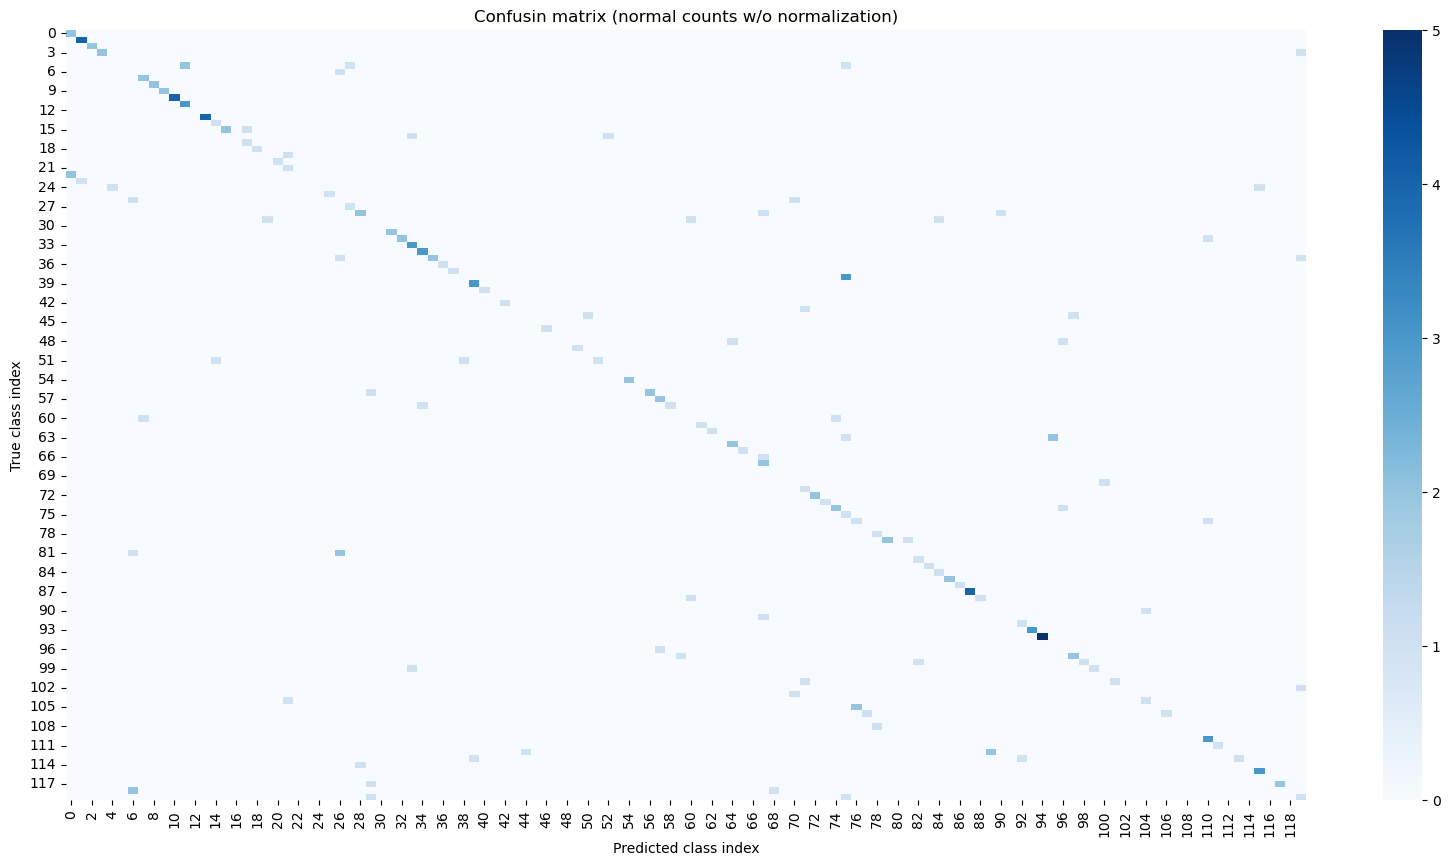

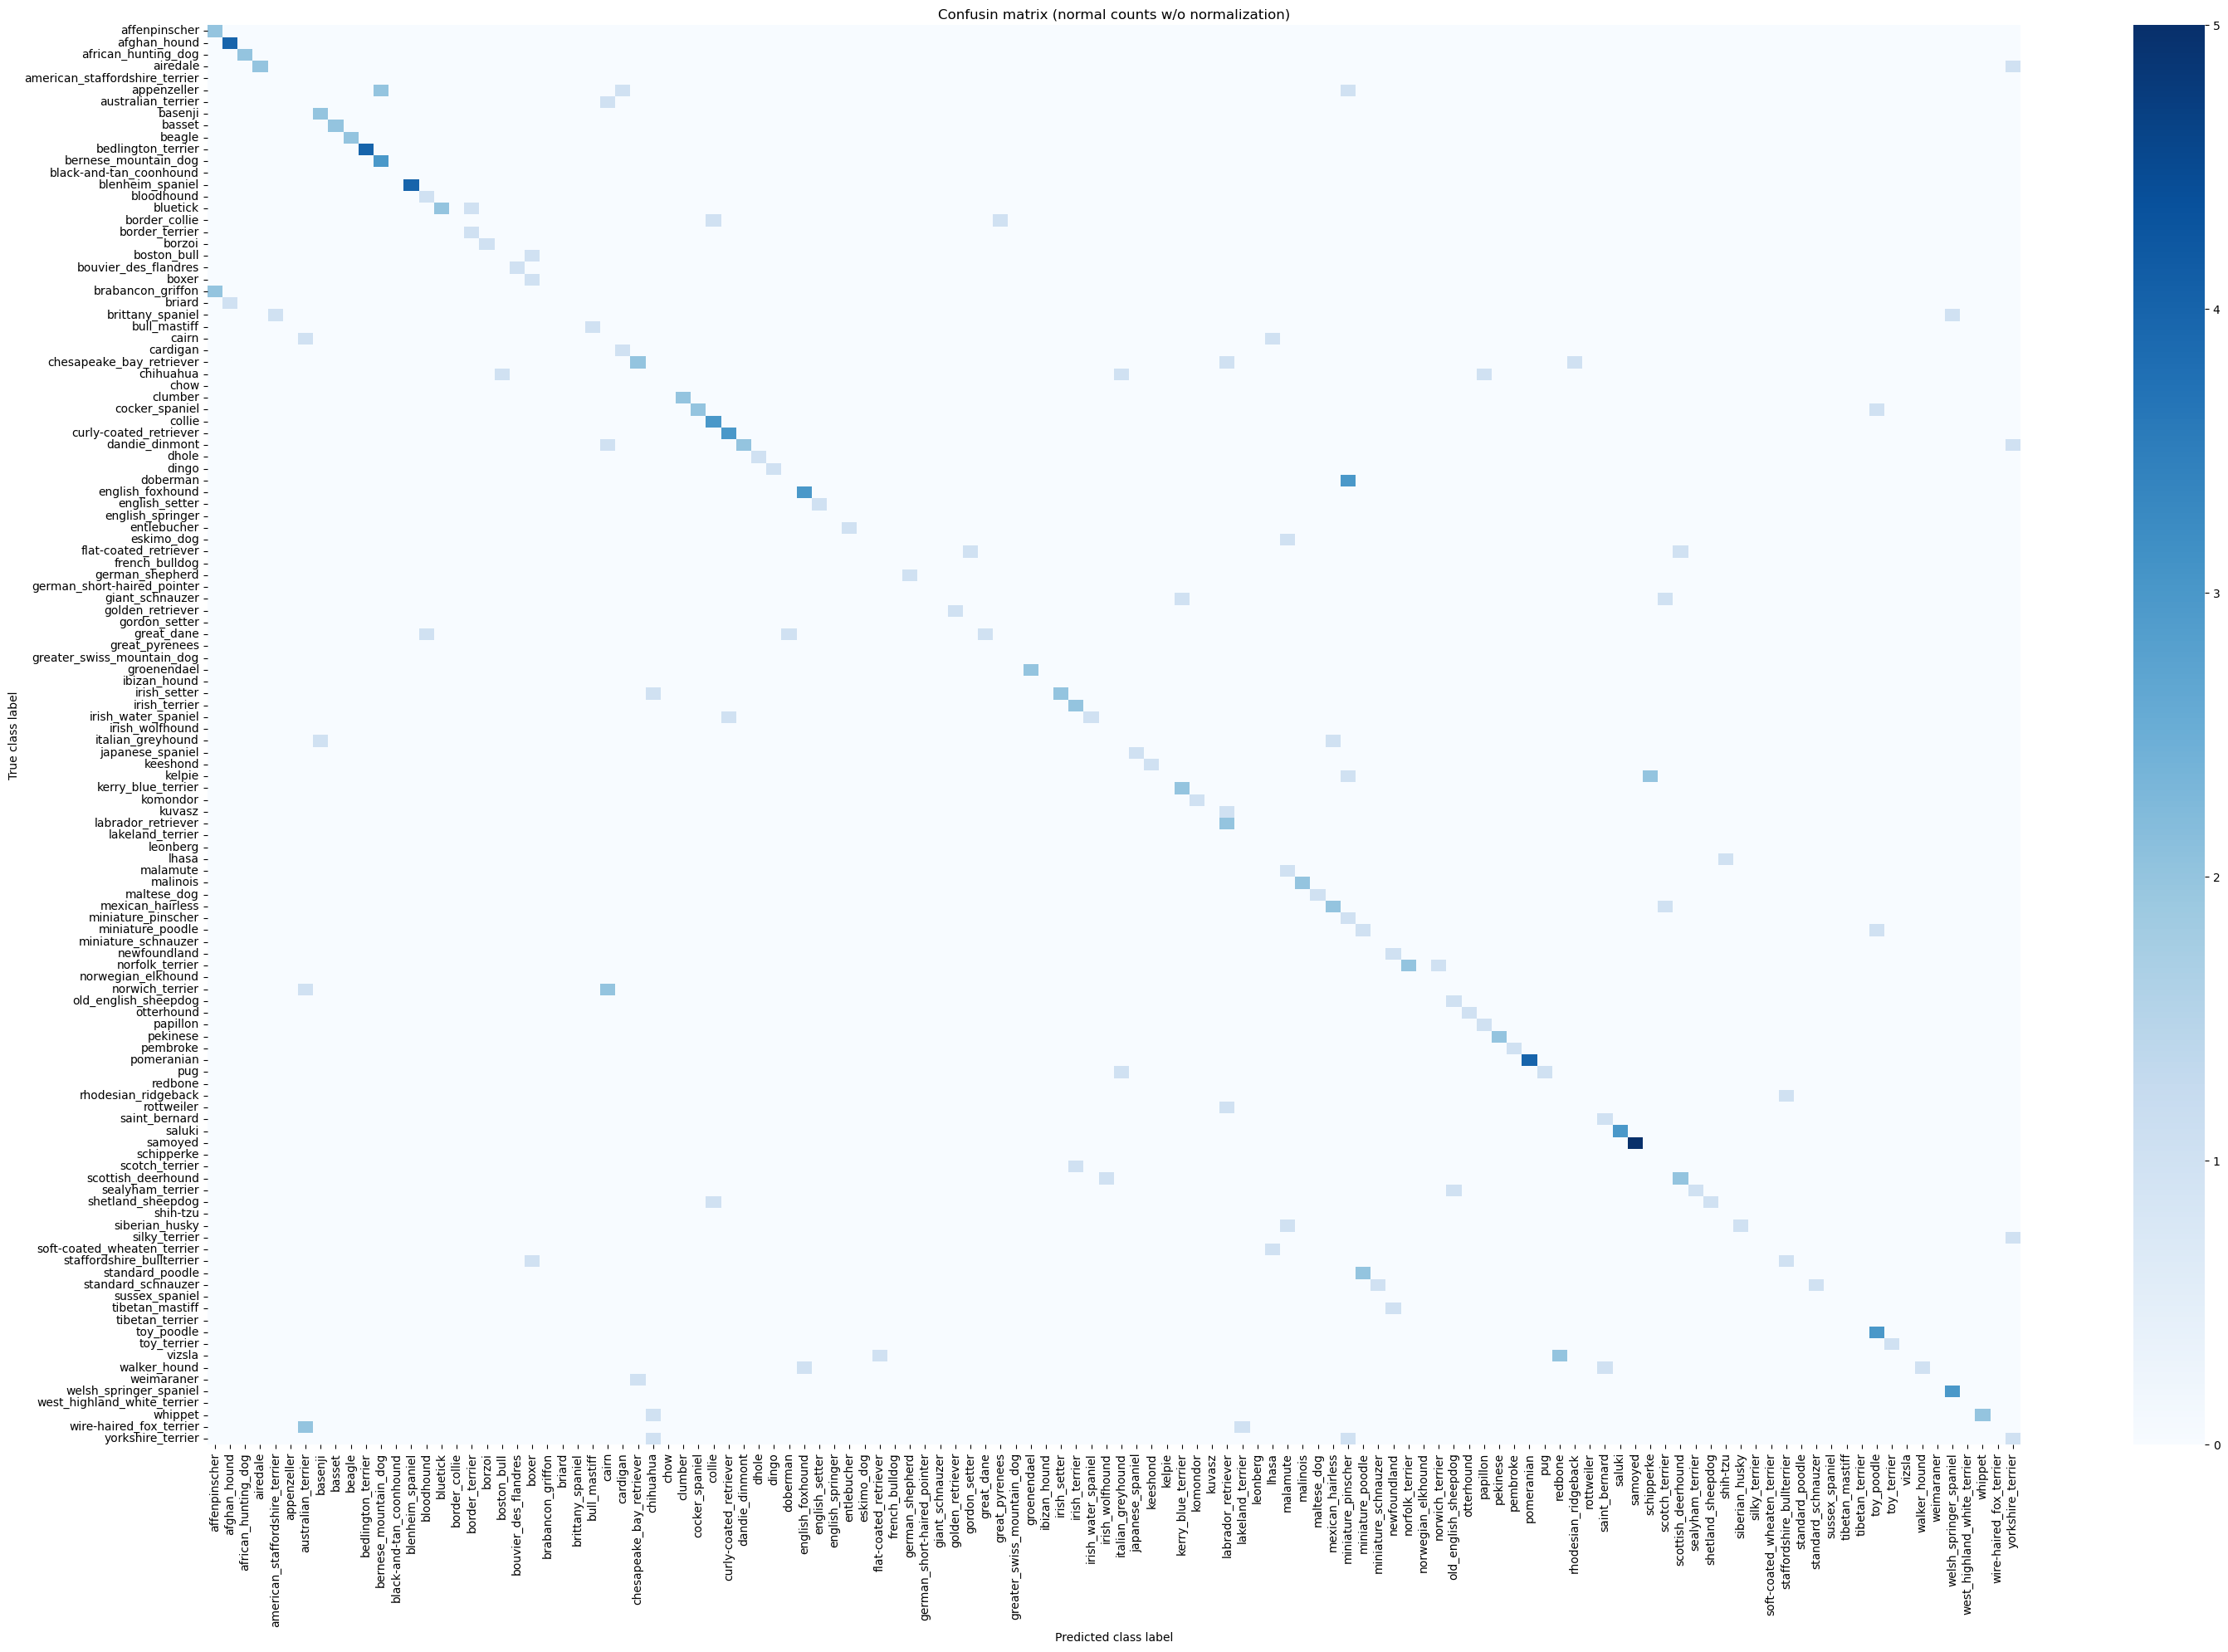

In [106]:
# 6.) Plotting the simple confusion matrix
import seaborn as sns

# Only indexes
plt.figure(figsize=(20, 10))
sns.heatmap(cm,
            cmap="Blues")
plt.title("Confusin matrix (normal counts w/o normalization)")
plt.xlabel("Predicted class index")
plt.ylabel("True class index")
plt.show()

# With labels
plt.figure(figsize=(30, 20))
sns.heatmap(cm,
            cmap="Blues",
            xticklabels=unique_breeds,
            yticklabels=unique_breeds)
plt.title("Confusin matrix (normal counts w/o normalization)")
plt.xlabel("Predicted class label")
plt.ylabel("True class label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show();

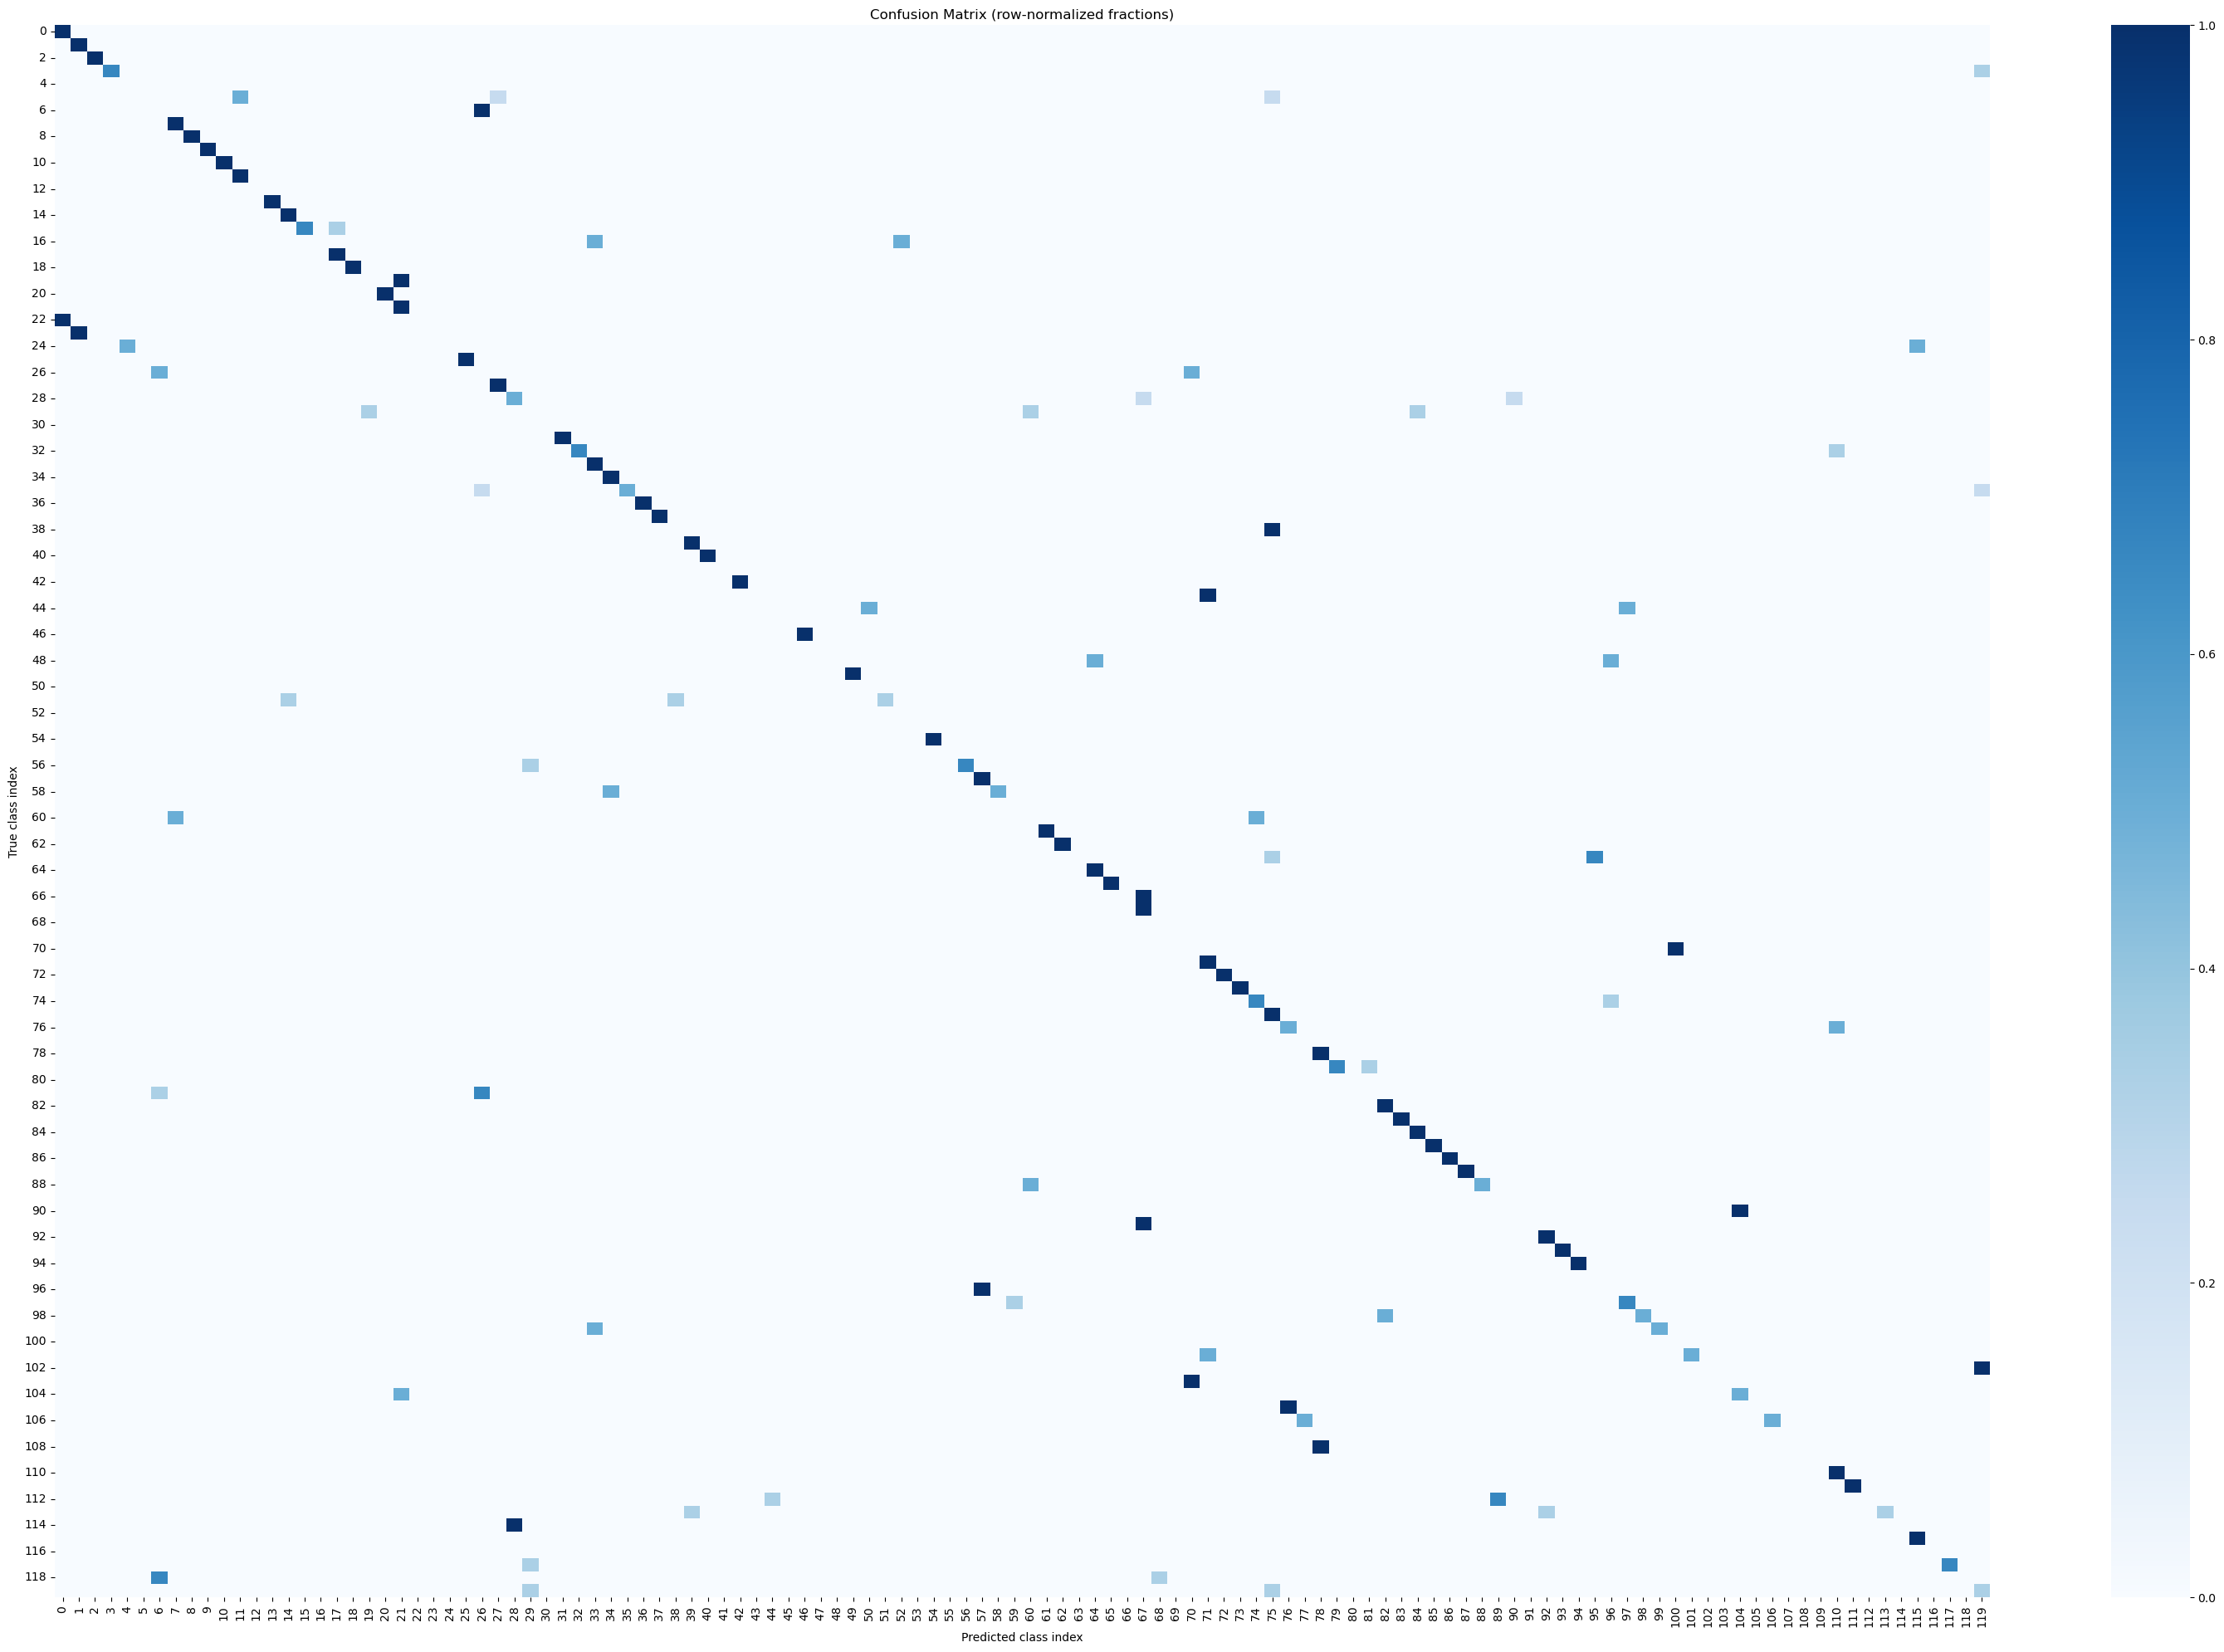

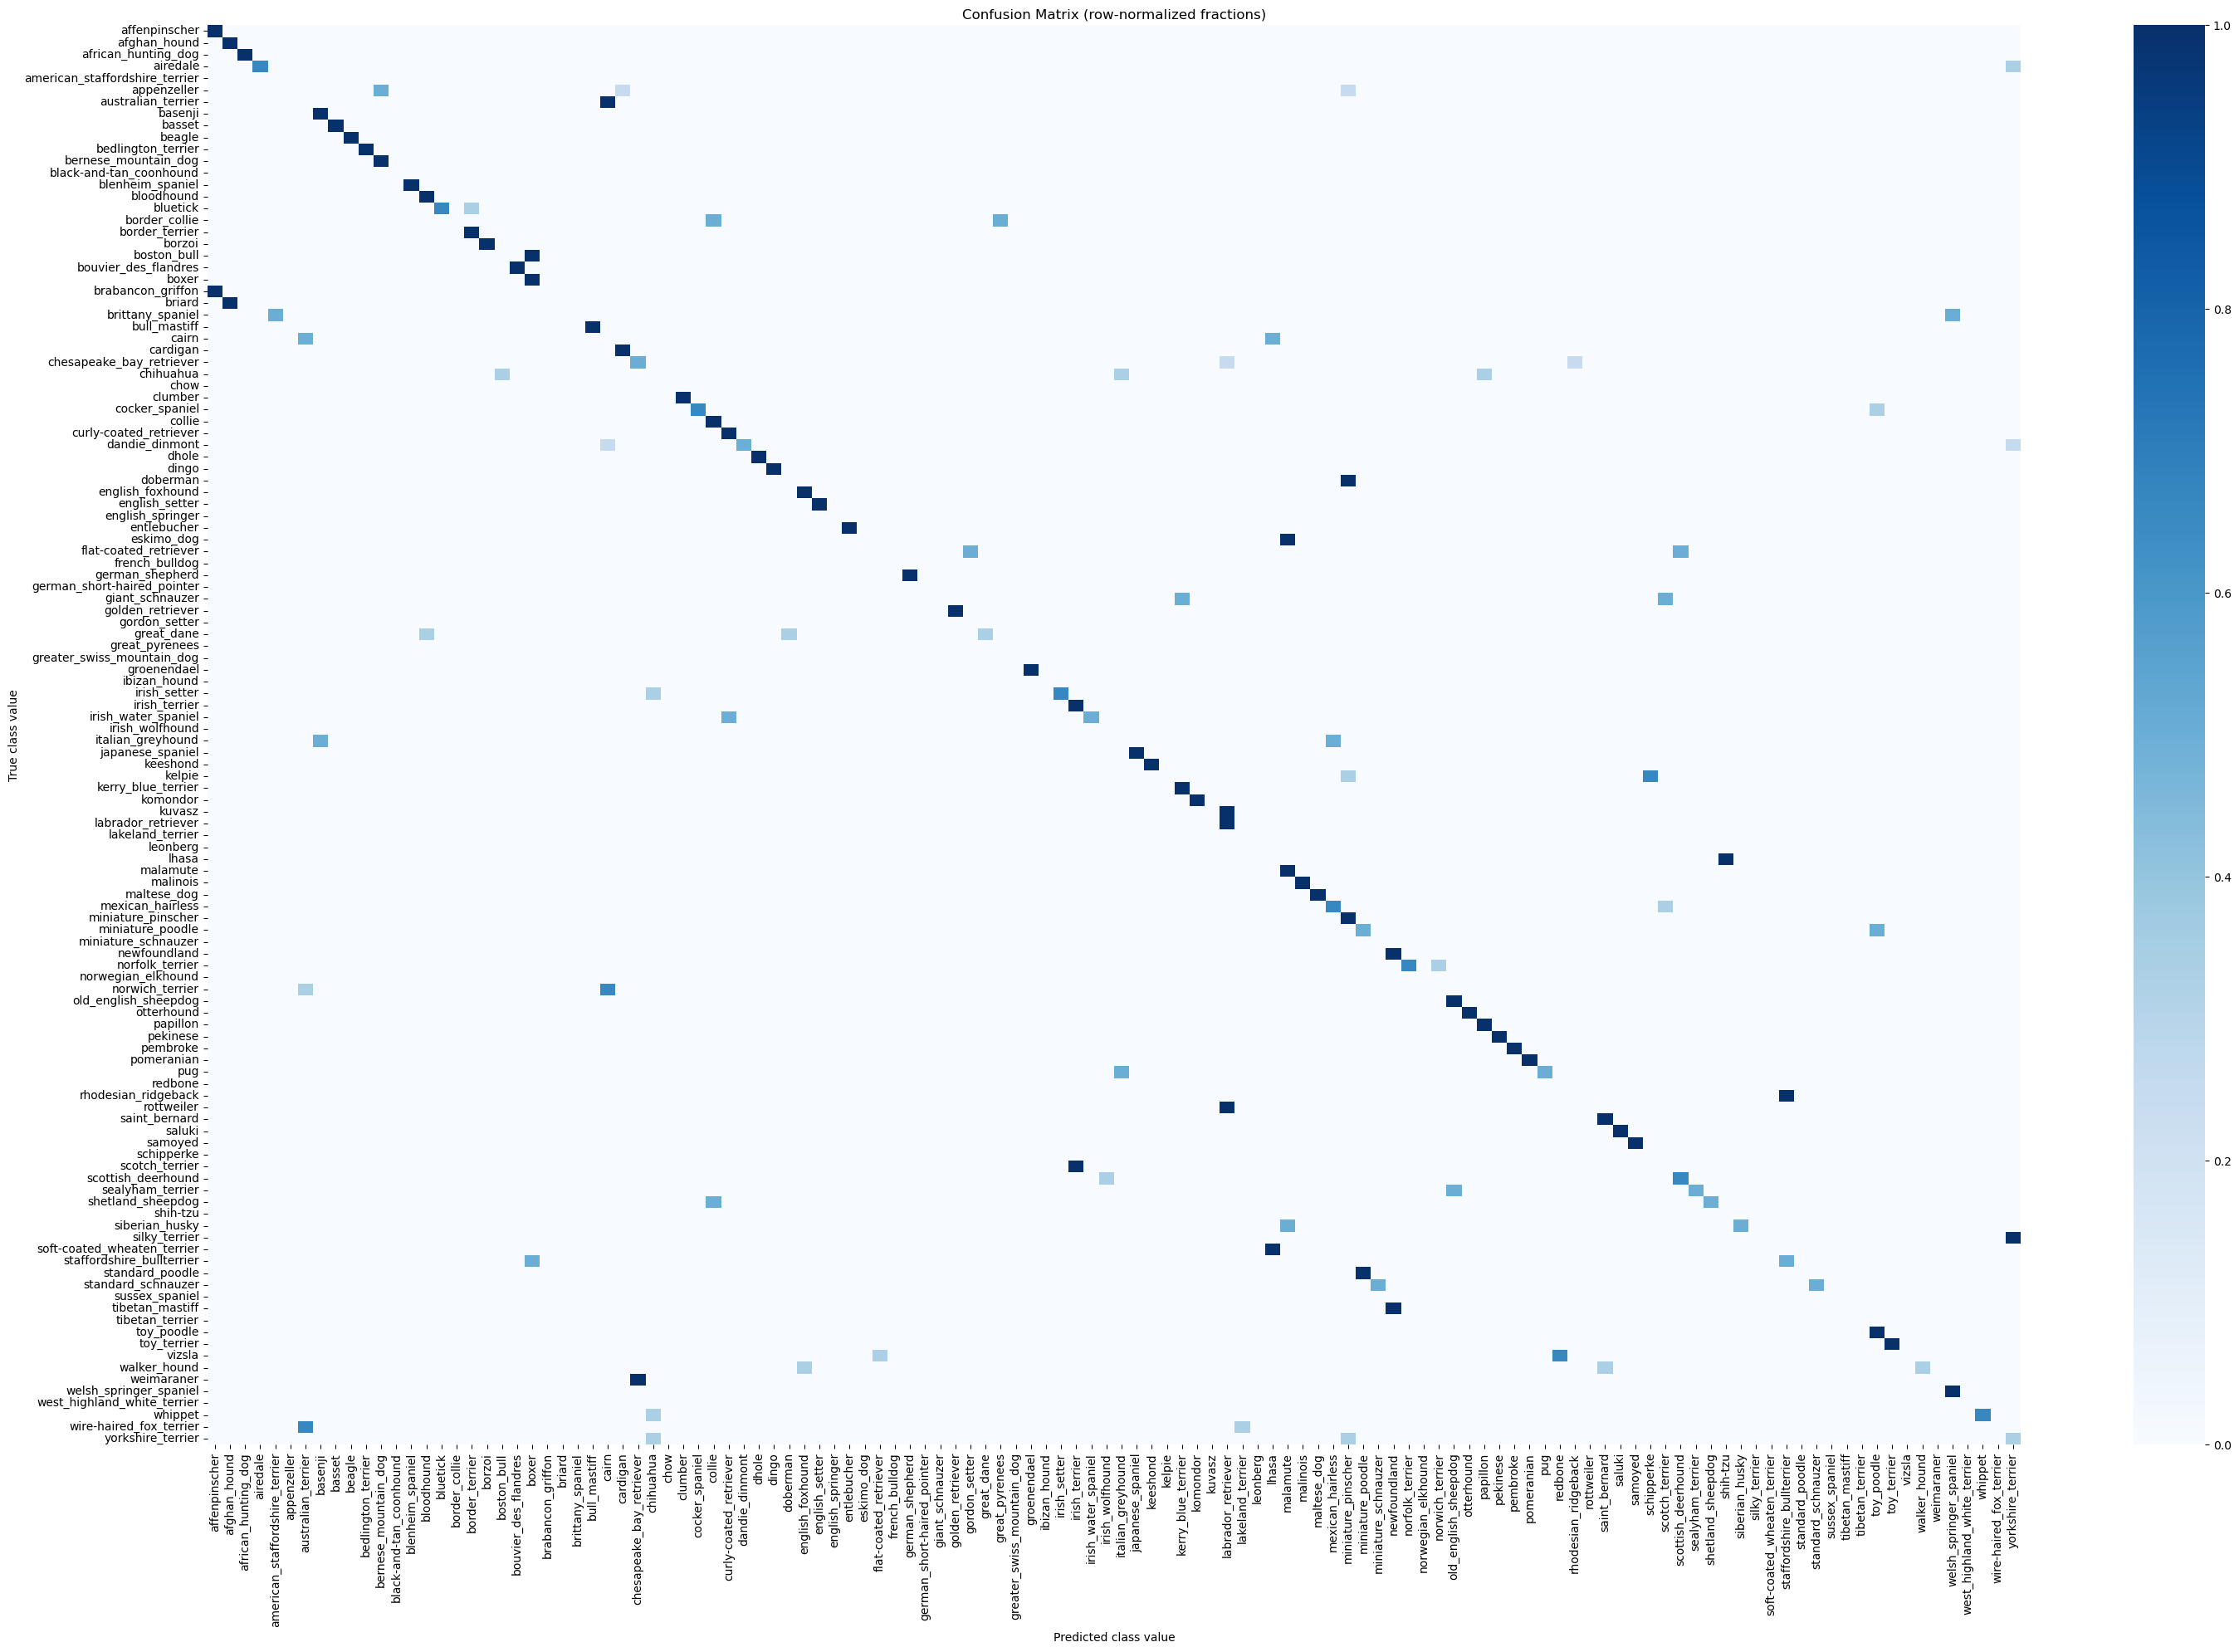

In [107]:
# 7.) Plotting Confusion matrix (Row-normalized) -> better than above

# Only indexes
plt.figure(figsize=(30,20))
sns.heatmap(cm_norm,
            cmap="Blues")
plt.title("Confusion Matrix (row-normalized fractions)")
plt.xlabel("Predicted class index")
plt.ylabel("True class index")
plt.tight_layout()
plt.show()

# With values
plt.figure(figsize=(30, 20))
sns.heatmap(cm_norm,
            cmap="Blues",
            xticklabels=unique_breeds,
            yticklabels=unique_breeds)
plt.title("Confusion Matrix (row-normalized fractions)")
plt.xlabel("Predicted class value")
plt.ylabel("True class value")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show();

---

## **Saving and reloading a trained model**

In [108]:
# Create a function to save a model 

def save_model(model, suffix=None):
    """
    Saves a given model in a models directory and appends a suppix (string).
    """
    
    # Create a model directory pathname with current time
    modeldir = os.path.join("./models", datetime.datetime.now().strftime("%Y%m%d-%H%M%s"))
    model_path = modeldir + "-" + suffix + ".keras"  # Save format of model (.h5 is redundent and old now)
    print(f"Saving model to: {model_path} ...")
    model.save(model_path)
    return model_path

In [109]:
# Create a function to load a trained model

def load_model(model_path):
    """
    Loads a save model from a specified path.
    """
    print(f"Loading saved model from: {model_path} ...")
    model = tf.keras.models.load_model(model_path)   # model = tf.keras.models.load_model(model_path,
                                                                                                                          # custom_objects={"KerasLayer":hub.KerasLayer}  -> for older version "hub.KerasLayer(MODEL_URL)" is used for building a model
    return model
    

**Now we've got functions to save and load a trained model, let's make sure they work!**

In [110]:
# Save our model trained on 1000 images
save_model(model, suffix="1000-images-mobilnetv2-Adam")

Saving model to: ./models/20260506-18261778091966-1000-images-mobilnetv2-Adam.keras ...


'./models/20260506-18261778091966-1000-images-mobilnetv2-Adam.keras'

In [111]:
# Load a trained model
loaded_1000_image_model = load_model("./models/20260506-16011778083270-1000-images-mobilnetv2-Adam.keras")

Loading saved model from: ./models/20260506-16011778083270-1000-images-mobilnetv2-Adam.keras ...


In [112]:
# Evaluate the pre-saved model
model.evaluate(val_data)

7/7 [==============================] - 1s 120ms/step - loss: 1.4376 - accuracy: 0.6150


[1.4376379251480103, 0.6150000095367432]

In [113]:
# Evaluate the loaded model
loaded_1000_image_model.evaluate(val_data)

7/7 [==============================] - 15s 92ms/step - loss: 1.4414 - accuracy: 0.6300


[1.4413573741912842, 0.6299999952316284]

---

## **Training a big dog model 🐶 (on the full data)**

In [114]:
len(X), len(y)  # Filenames and labels

(10222, 10222)

In [115]:
X[:10]

['dataset/dog-breed-identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'dataset/dog-breed-identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'dataset/dog-breed-identification/train/001cdf01b096e06d78e9e5112d419397.jpg',
 'dataset/dog-breed-identification/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'dataset/dog-breed-identification/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'dataset/dog-breed-identification/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 'dataset/dog-breed-identification/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'dataset/dog-breed-identification/train/002a283a315af96eaea0e28e7163b21b.jpg',
 'dataset/dog-breed-identification/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'dataset/dog-breed-identification/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [116]:
y[:10]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

![TensorFlow Workflow](./assets/images/unstructured-data-tesnorflow-workflow.png)

In [117]:
# Create a data batch with the full dataset
full_data = create_data_batches(X, y)

Creating training data batches...


In [118]:
full_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [119]:
# Create a model for full model
full_model = create_model()

Building model with: https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/130-224-classification/1


In [120]:
# Create full model callbacks
full_model_tensorboard = create_tensorboard_callbacks()

# No validation set when training on all the data, so we can't monitor validation accuracy
# Create NEW early stopping callback
full_model_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

**Note:** Running this cell below will take a little while (maybe up to `30 mins` for the `first epochs`) because GPU we are using in the runtime has to load all of the images into memory.

In [121]:
# # Fit the full model to the full data
# full_model.fit(x=full_data,
#                epochs=NUM_EPOCHS,
#                callbacks=[full_model_tensorboard, full_model_early_stopping])

In [122]:
# save_model(full_model, suffix="full-image-set-mobilnetv2-Adam")

In [123]:
loaded_full_model = load_model('./models/20260506-17291778088573-full-image-set-mobilnetv2-Adam.keras')

Loading saved model from: ./models/20260506-17291778088573-full-image-set-mobilnetv2-Adam.keras ...


In [124]:
len(X)

10222

## **Making predictions on the test dataset**

Since our model has been trained on images in the form of Tensor batches, to make predictions on the test data, we'll have to get it into the same format.

Luckily we created `create_data_batches()` earlier which can take a list of filenames as input and convert them into Tensor batches.

**To make predictiopns on the test data, we'll:**
* Get the test image filenames ✅
* Convert the file names into test data batches using `create_data_batches()` and setting the `test_data` parameter to the `True` (Since the test data doesn't have the labels). ✅
* Make a prediction array by passing the test batches to the `predict` method called on our model.

In [125]:
# Load test image filenames
test_path = str(TEST_DIR)
test_filenames = [test_path + "/" + fname for fname in os.listdir(test_path)]
test_filenames[:10]

['dataset/dog-breed-identification/test/000621fb3cbb32d8935728e48679680e.jpg',
 'dataset/dog-breed-identification/test/00102ee9d8eb90812350685311fe5890.jpg',
 'dataset/dog-breed-identification/test/0012a730dfa437f5f3613fb75efcd4ce.jpg',
 'dataset/dog-breed-identification/test/001510bc8570bbeee98c8d80c8a95ec1.jpg',
 'dataset/dog-breed-identification/test/001a5f3114548acdefa3d4da05474c2e.jpg',
 'dataset/dog-breed-identification/test/00225dcd3e4d2410dd53239f95c0352f.jpg',
 'dataset/dog-breed-identification/test/002c2a3117c2193b4d26400ce431eebd.jpg',
 'dataset/dog-breed-identification/test/002c58d413a521ae8d1a5daeb35fc803.jpg',
 'dataset/dog-breed-identification/test/002f80396f1e3db687c5932d7978b196.jpg',
 'dataset/dog-breed-identification/test/0036c6bcec6031be9e62a257b1c3c442.jpg']

In [126]:
len(test_filenames)

10357

In [127]:
# Create test databatch
test_data = create_data_batches(test_filenames, test_data=True)

Creating test data batches...


In [128]:
test_data

<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

**Note:** Calling `predict()` on our full model and passing it the test data batch will take a long time to run (~ 1hr)

In [ ]:
# Make predictions on test data batch using the loaded full model
test_predictions = loaded_full_model.predict(test_data,
                                     verbose=1)

324/324 [==============================] - 60s 167ms/step


In [ ]:
# Save predictions (NumPy array) to csv file (for access later)
np.savetxt(
    PROJECT_ROOT / "test_predictions.csv",
    test_predictions,
    delimiter=","
)

In [131]:
# Load predictions (NumPy array) from csv file
test_predictions = np.loadtxt(
    PROJECT_ROOT/"test_predictions.csv",
    delimiter=","
)

In [132]:
test_predictions[:10]

array([[3.43682900e-13, 1.52652446e-09, 1.12174181e-12, ...,
        3.63451377e-15, 2.22908289e-10, 3.27355854e-09],
       [1.04168174e-09, 2.20361836e-12, 2.29312111e-10, ...,
        2.90769448e-12, 4.09806147e-11, 7.27418750e-11],
       [3.49154949e-09, 2.30030605e-06, 7.62551697e-13, ...,
        6.55249854e-10, 7.01582070e-10, 7.70489714e-11],
       ...,
       [1.57112967e-09, 4.81134143e-12, 7.39187669e-11, ...,
        7.09195235e-13, 1.27572161e-10, 9.86917796e-13],
       [1.27891520e-08, 1.68676223e-07, 8.08263012e-10, ...,
        2.60444253e-08, 2.02534295e-07, 1.00263461e-11],
       [1.05804254e-11, 2.56116994e-09, 8.88292426e-11, ...,
        1.84697899e-11, 3.16214312e-11, 4.11955192e-10]])

In [133]:
test_predictions.shape

(10357, 120)

---

### **Preparing test dataset predictions for Kaggle**

Looking at the Kaggle sample submission, we can see that it expects our model's prediction probabilities in a dataframe containing:

- an `id` column
- one column for each dog breed with probabilities

([Evaluation Page](https://www.kaggle.com/competitions/dog-breed-identification/overview/evaluation))

To get the data in this format, we'll:
* Create a pandas DataFrame with an `id` column as well as a column for each dog breed with probabilities. ✅
* Add data to the `id` column by extracting the test image `id`'s from the filepaths. ✅
* Add data(prediction probabilities) to each of the dog breed columns.
* Export the DataFrame as a CSV to submit it to the kaggle.

In [135]:
["id"] + list(unique_breeds)

['id',
 'affenpinscher',
 'afghan_hound',
 'african_hunting_dog',
 'airedale',
 'american_staffordshire_terrier',
 'appenzeller',
 'australian_terrier',
 'basenji',
 'basset',
 'beagle',
 'bedlington_terrier',
 'bernese_mountain_dog',
 'black-and-tan_coonhound',
 'blenheim_spaniel',
 'bloodhound',
 'bluetick',
 'border_collie',
 'border_terrier',
 'borzoi',
 'boston_bull',
 'bouvier_des_flandres',
 'boxer',
 'brabancon_griffon',
 'briard',
 'brittany_spaniel',
 'bull_mastiff',
 'cairn',
 'cardigan',
 'chesapeake_bay_retriever',
 'chihuahua',
 'chow',
 'clumber',
 'cocker_spaniel',
 'collie',
 'curly-coated_retriever',
 'dandie_dinmont',
 'dhole',
 'dingo',
 'doberman',
 'english_foxhound',
 'english_setter',
 'english_springer',
 'entlebucher',
 'eskimo_dog',
 'flat-coated_retriever',
 'french_bulldog',
 'german_shepherd',
 'german_short-haired_pointer',
 'giant_schnauzer',
 'golden_retriever',
 'gordon_setter',
 'great_dane',
 'great_pyrenees',
 'greater_swiss_mountain_dog',
 'groenen

In [137]:
# Create a pandas DataFrame with empty columns
preds_df = pd.DataFrame(columns=["id"] + list(unique_breeds))
preds_df

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier


In [140]:
test_path

'dataset/dog-breed-identification/test'

In [144]:
# Append test image ID's to predictions DataFrame
test_ids = [os.path.splitext(path)[0] for path in os.listdir(test_path)]
preds_df["id"] = test_ids

In [141]:
os.path.split(test_filenames[0])

('dataset/dog-breed-identification/test',
 '000621fb3cbb32d8935728e48679680e.jpg')

In [145]:
preds_df.head()

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,000621fb3cbb32d8935728e48679680e,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00102ee9d8eb90812350685311fe5890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0012a730dfa437f5f3613fb75efcd4ce,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,001510bc8570bbeee98c8d80c8a95ec1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,001a5f3114548acdefa3d4da05474c2e,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [146]:
# Add the prediction probabilities to each dog breed column
preds_df[list(unique_breeds)] = test_predictions
preds_df.head()

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,000621fb3cbb32d8935728e48679680e,3.436829e-13,1.526524e-09,1.121742e-12,1.438470e-16,1.988051e-14,4.185169e-11,1.003288e-14,7.201402e-14,3.713906e-11,...,7.213476e-13,1.822462e-12,8.578047e-14,8.469391e-12,3.730098e-15,9.002732e-12,1.303610e-16,3.634514e-15,2.229083e-10,3.273559e-09
1,00102ee9d8eb90812350685311fe5890,1.041682e-09,2.203618e-12,2.293121e-10,3.974760e-14,4.347146e-08,1.026303e-10,1.005044e-09,6.825099e-09,2.559924e-13,...,5.027190e-08,1.066929e-11,8.332601e-11,4.622679e-11,1.648513e-10,9.494597e-13,1.596014e-08,2.907694e-12,4.098061e-11,7.274188e-11
2,0012a730dfa437f5f3613fb75efcd4ce,3.491549e-09,2.300306e-06,7.625517e-13,5.315150e-09,2.189864e-15,6.150060e-13,1.864327e-13,5.179407e-15,9.861991e-11,...,2.894111e-09,6.196522e-13,1.757343e-09,3.069588e-11,4.160696e-09,1.254364e-04,5.461611e-11,6.552499e-10,7.015821e-10,7.704897e-11
3,001510bc8570bbeee98c8d80c8a95ec1,3.000330e-05,1.074779e-09,4.355173e-10,2.274343e-09,1.990957e-09,7.211650e-10,1.302279e-10,2.728666e-09,1.033344e-09,...,1.216480e-11,3.288945e-13,4.509771e-09,4.764800e-14,1.144176e-07,6.111345e-11,7.640793e-11,2.688139e-06,3.953091e-10,7.681917e-10
4,001a5f3114548acdefa3d4da05474c2e,1.490541e-03,4.671839e-07,1.464324e-09,1.704796e-09,1.381503e-12,1.226564e-11,6.026232e-09,3.551022e-08,8.718103e-09,...,8.159414e-08,1.243825e-09,5.376628e-11,3.422139e-11,2.428681e-09,1.350763e-07,9.280332e-10,3.998144e-09,1.681547e-06,6.268715e-09


In [147]:
preds_df.shape

(10357, 121)

In [148]:
# Save our predictions dataframe to CSV for submission to Kaggle
preds_df.to_csv(
    str(PROJECT_ROOT) + "full_model_predictions_submission_1_molbilnetv2.csv",
    index=False)

![Submission on Kaggle](./assets/images/Submission%20on%20Kaggle.png)

> Lower Score = Better Score

---

## **Making Predictions on Custom Images**

**To make predictions on custom images, we'll:**

* Get the filepaths of own images.
* Turn the filepaths into data batches using `create_data_batches()`. And since our custom images won't have labels, we set the `test_data` parameter to true.
* Pass the custom image data batch to our model's `predict()` method.
* Convert the predictions output probabilities to predicting labels.
* Compare the predicted labels to the custom images.

In [156]:
# Get the custom image filepath
custom_path = "./assets/images/Custom dog images"
custom_image_path = [custom_path + "/" + fname for fname in os.listdir(custom_path)]

In [157]:
custom_image_path

['./assets/images/Custom dog images/dog-photo-1.jpg',
 './assets/images/Custom dog images/dog-photo-2.jpeg',
 './assets/images/Custom dog images/dog-photo-3.jpeg',
 './assets/images/Custom dog images/dog-photo-4.jpg',
 './assets/images/Custom dog images/dog-photo-5.jpeg']

In [158]:
# Turn custom images into Batch dataset
custom_data = create_data_batches(custom_image_path, test_data=True)
custom_data

Creating test data batches...


<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

In [159]:
# Make predictions on the custom data
custom_preds = loaded_full_model.predict(custom_data)

1/1 [==============================] - 2s 2s/step


In [162]:
custom_preds.shape

(5, 120)

In [163]:
# Get custom image prediction labels
custom_pred_labels = [get_pred_label(custom_preds[i]) for i in range(len(custom_preds))]
custom_pred_labels

['beagle',
 'labrador_retriever',
 'labrador_retriever',
 'golden_retriever',
 'labrador_retriever']

In [164]:
# Get the custom images (Our unbachify() function won't work since there aren't labels...maybe we could fix this later)
custom_images = []
# Loop through unbatched data
for image in custom_data.unbatch().as_numpy_iterator():
    custom_images.append(image)

2026-05-06 19:41:38.828068: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [165]:
custom_images

[array([[[0.882353  , 0.86666673, 0.8313726 ],
         [0.882353  , 0.86666673, 0.8313726 ],
         [0.882353  , 0.86666673, 0.8313726 ],
         ...,
         [0.8862746 , 0.882353  , 0.86666673],
         [0.8862746 , 0.882353  , 0.86666673],
         [0.89019614, 0.8862746 , 0.8705883 ]],
 
        [[0.882353  , 0.86666673, 0.8313726 ],
         [0.882353  , 0.86666673, 0.8313726 ],
         [0.882353  , 0.86666673, 0.8313726 ],
         ...,
         [0.8862746 , 0.882353  , 0.86666673],
         [0.8862746 , 0.882353  , 0.86666673],
         [0.8862746 , 0.882353  , 0.86666673]],
 
        [[0.882353  , 0.86666673, 0.8313726 ],
         [0.882353  , 0.86666673, 0.8313726 ],
         [0.882353  , 0.86666673, 0.8313726 ],
         ...,
         [0.8862746 , 0.882353  , 0.86666673],
         [0.8862746 , 0.882353  , 0.86666673],
         [0.8862746 , 0.882353  , 0.86666673]],
 
        ...,
 
        [[0.29915994, 0.24033642, 0.12661092],
         [0.3084042 , 0.24958067, 0.13585

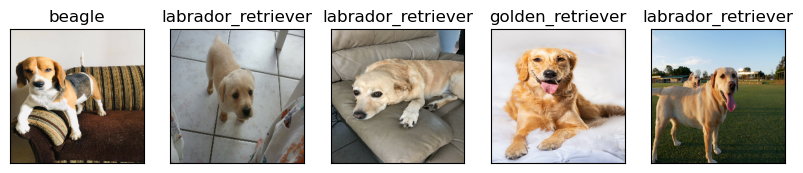

In [168]:
# Check custom predictions
plt.figure(figsize=(10, 10))
for i, image in enumerate(custom_images):
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.title(custom_pred_labels[i])
    plt.imshow(image)

**Wohhh!! all are correct**

---